# Indoor Air Pollution Graph Pipeline

## Phase 1: Setup and Configuration


In [1]:
from pathlib import Path
import random

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import torch
import torch_geometric
import sklearn
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from scipy import stats

# -------------------------------
# Reproducibility
# -------------------------------
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# -------------------------------
# Paths
# -------------------------------
PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / 'data').exists():
    PROJECT_DIR = PROJECT_DIR.parent

DATA_DIR = PROJECT_DIR / 'data'
ONTOLOGY_DIR = PROJECT_DIR / 'ontology'
OUTPUT_DIR = PROJECT_DIR / 'outputs'
FIG_DIR = OUTPUT_DIR / 'figures'
GRAPH_DIR = OUTPUT_DIR / 'graphs'
MODEL_DIR = OUTPUT_DIR / 'models'

for d in [OUTPUT_DIR, FIG_DIR, GRAPH_DIR, MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

LAB_CSV = DATA_DIR / 'laboratory.csv'
APT_CANDIDATES = [
    DATA_DIR / 'one_room_apartement.csv',
    DATA_DIR / 'one_room_apartment.csv'
 ]

def pick_existing_file(candidates):
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(f'None of these files exists: {candidates}')

APARTMENT_CSV = pick_existing_file(APT_CANDIDATES)
DATA_DESCRIPTION_TXT = DATA_DIR / 'DataDescription.txt'
ONTOLOGY_V2_TTL = ONTOLOGY_DIR / 'iaq_ontology_v2.ttl'

if not LAB_CSV.exists():
    raise FileNotFoundError(f'Missing required file: {LAB_CSV}')
if not DATA_DESCRIPTION_TXT.exists():
    raise FileNotFoundError(f'Missing required file: {DATA_DESCRIPTION_TXT}')

LAB_PATH = LAB_CSV
APT_PATH = APARTMENT_CSV

# -------------------------------
# Danger thresholds and labels
# -------------------------------
CO2_DANGER = 1000.0
CO_DANGER = 200.0
PM25_DANGER = 35.0
PM10_DANGER = 101.0
VOC_DANGER = 500.0
SO2_DANGER = 125.0
HEALTH_GAS = -200.0
HEALTH_FIRE = -800.0

# Compatibility aliases used in later cells
SEED = RANDOM_SEED
TVOC_DANGER = VOC_DANGER
HEALTH_GAS_ALARM = HEALTH_GAS
HEALTH_FIRE_ALARM = HEALTH_FIRE

DANGER_THRESHOLDS = {
    'co2': CO2_DANGER,
    'co': CO_DANGER,
    'pm2_5': PM25_DANGER,
    'pm10': PM10_DANGER,
    'tvoc': VOC_DANGER
}

ANOMALY_DATES = {
    'power_outage': '2023-04-17',
    'fire_event': '2023-05-21',
    'sensor_error': '2023-07-09'
}

LABEL_TO_CLASS = {
    'clean': 0,
    'polluted': 1,
    'gas_alarm': 2,
    'fire_alarm': 3
}

# -------------------------------
# Sensor columns used in graph modeling
# -------------------------------
SENSOR_COLUMNS = [
    'TypPS', 'oxygen', 'pm10', 'cnt0_5', 'co', 'temperature', 'performance',
    'co2', 'measuretime', 'so2', 'no2', 'cnt5', 'pm1', 'cnt1', 'dewpt',
    'tvoc', 'pressure', 'cnt10', 'dCO2dt', 'sound_max', 'health',
    'temperature_o2', 'cnt2_5', 'o3', 'humidity', 'dHdt', 'humidity_abs',
    'sound', 'pm2_5', 'cnt0_3'
 ]

device = 'cuda' if torch.cuda.is_available() else 'cpu'
DEVICE = torch.device(device)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

## Phase 2: Data Loading and Exploration
This phase loads both datasets, checks data quality, labels anomaly periods, and creates the required key sensor time-series figure.

In [2]:
# Cell 2: Load both CSV files and prepare time column
df_lab = pd.read_csv(LAB_PATH)
df_apt = pd.read_csv(APT_PATH)

for df in (df_lab, df_apt):
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

df_lab = df_lab.sort_values('timestamp').reset_index(drop=True)
df_apt = df_apt.sort_values('timestamp').reset_index(drop=True)

print('Laboratory shape:', df_lab.shape)
display(df_lab.head(5))

print('Apartment shape:', df_apt.shape)
display(df_apt.head(5))

Laboratory shape: (51186, 31)


,TypPS,oxygen,pm10,cnt0_5,co,temperature,performance,co2,measuretime,so2,...,health,temperature_o2,cnt2_5,o3,humidity,dHdt,humidity_abs,sound,pm2_5,cnt0_3
0,14.966,20.688,0.007,4.867,1.522,20.867,910.0,548.505,1876,38.461,...,968.0,24.841,0.014,11.550,44.833,-0.03,8.182,21.999,0.0,16.234
1,14.996,20.687,0.001,3.496,1.521,20.865,915.0,543.500,1887,38.462,...,942.0,24.845,0.002,11.520,44.784,-0.06,8.172,24.962,0.0,14.324
2,15.000,20.687,0.000,5.134,1.521,20.866,916.0,542.134,1858,38.463,...,938.0,24.834,0.000,11.506,44.768,-0.07,8.170,25.293,0.0,15.826
3,14.081,20.688,0.213,4.223,1.521,20.864,918.0,539.314,1856,38.462,...,936.0,24.834,0.618,11.438,44.766,-0.04,8.169,26.403,0.0,12.719
4,14.258,20.687,0.152,8.701,1.522,20.867,915.0,543.551,1862,38.462,...,935.0,24.838,0.543,11.393,44.768,0.00,8.170,25.934,0.0,26.107


Apartment shape: (12446, 31)


,TypPS,oxygen,pm10,cnt0_5,co,temperature,performance,co2,measuretime,so2,...,health,temperature_o2,cnt2_5,o3,humidity,dHdt,humidity_abs,sound,pm2_5,cnt0_3
0,1.995,20.863,6.004,273.935,1.726,23.718,805.0,490.458,1868,518.956,...,758.0,27.774,0.923,26.690,60.385,0.04,12.983,51.839,5.402,859.499
1,1.689,20.863,6.891,296.490,1.726,23.715,806.0,490.505,1867,520.396,...,715.0,27.762,0.739,26.594,60.377,0.03,12.980,52.092,6.451,932.282
2,2.854,20.863,7.486,268.740,1.726,23.716,808.0,489.080,1857,520.139,...,742.0,27.764,3.002,26.501,60.358,0.00,12.977,51.313,6.107,851.850
3,1.635,20.862,5.874,262.821,1.726,23.719,807.0,488.189,1881,518.782,...,746.0,27.748,1.287,26.611,60.426,0.03,12.993,53.420,5.489,829.355
4,1.579,20.864,7.068,297.597,1.725,23.712,809.0,485.401,1880,516.398,...,717.0,27.760,0.527,26.681,60.435,0.03,12.990,52.284,6.723,926.864


In [3]:
# Cell 3: Data quality checks
def quality_report(df, name):
    print(f'\n===== {name} =====')

    print('\nMissing values per column:')
    display(df.isnull().sum().to_frame('missing_count'))

    print('\nDescriptive statistics for sensor columns:')
    display(df[SENSOR_COLUMNS].describe().T)

    duplicate_timestamps = df['timestamp'].duplicated().sum()
    print(f'\nDuplicate timestamps: {duplicate_timestamps}')

    health_min = df['health'].min()
    health_max = df['health'].max()
    print(f'Health min: {health_min} | Health max: {health_max}')

    print('\nData types:')
    display(df.dtypes.astype(str).to_frame('dtype'))

    # Sensor offline hint: all values are zero in a column
    all_zero_cols = [col for col in SENSOR_COLUMNS if np.isclose(df[col].abs().sum(), 0.0)]
    if all_zero_cols:
        print('Potential offline sensors (all zeros):', all_zero_cols)
    else:
        print('No all-zero sensor columns found.')

quality_report(df_lab, 'Laboratory')
quality_report(df_apt, 'Apartment')


===== Laboratory =====

Missing values per column:


,missing_count
TypPS,0
oxygen,0
pm10,0
cnt0_5,0
co,0
temperature,0
performance,0
co2,0
measuretime,0
so2,0



Descriptive statistics for sensor columns:


,count,mean,std,min,25%,50%,75%,max
TypPS,51186.0,10.758746,5.318728,1.002000e+00,5.07800,14.1940,14.99800,15.000
oxygen,51186.0,20.906844,0.029213,2.068700e+01,20.89600,20.9110,20.92400,20.962
pm10,51186.0,1.268992,3.570237,0.000000e+00,0.00000,0.1380,1.05800,49.051
cnt0_5,51186.0,68.809345,103.657330,2.000000e-03,12.02500,31.7720,87.23750,1078.400
co,51186.0,1.569332,0.077995,1.209000e+00,1.51200,1.5520,1.60900,1.829
temperature,51186.0,20.690131,1.205284,1.833300e+01,19.64225,20.6570,21.60900,24.614
performance,51186.0,873.410503,82.777291,5.400000e+01,828.00000,895.0000,938.00000,987.000
co2,51186.0,520.591511,77.147816,4.249460e+02,460.72725,496.6540,559.09400,908.562
measuretime,51186.0,565.534189,254917.093286,-5.731870e+07,1763.00000,1807.0000,1873.00000,2208.000
so2,51186.0,109.077563,104.568768,-1.631560e+02,49.99375,107.8345,155.36250,2225.170



Duplicate timestamps: 0
Health min: 23.0 | Health max: 999.0

Data types:


...


Descriptive statistics for sensor columns:


,count,mean,std,min,25%,50%,75%,max
TypPS,12446.0,4.646627,3.614158,1.053000e+00,2.18125,2.9870,5.89350,15.000
oxygen,12446.0,20.872702,0.051421,2.068500e+01,20.84800,20.8810,20.91100,20.958
pm10,12446.0,8.886985,26.359851,0.000000e+00,1.34525,3.2090,10.25075,801.987
cnt0_5,12446.0,313.802609,1073.526810,2.933000e+00,83.75900,143.1430,355.04800,33554.400
co,12446.0,1.539373,0.084514,1.377000e+00,1.47300,1.5330,1.59500,1.834
temperature,12446.0,25.412464,2.293967,2.150500e+01,23.80625,25.0000,26.73775,33.698
performance,12446.0,610.803551,281.921019,0.000000e+00,464.25000,680.5000,846.00000,996.000
co2,12446.0,514.306575,103.011666,4.074600e+02,450.20850,479.6290,536.32825,1089.300
measuretime,12446.0,-3326.789009,517180.733276,-5.731870e+07,1863.00000,1875.0000,1886.00000,2282.000
so2,12446.0,577.368352,304.038099,-3.638170e+02,385.31675,506.2290,715.37250,1904.450



Duplicate timestamps: 0
Health min: -766.0 | Health max: 974.0

Data types:


,dtype
TypPS,float64
oxygen,float64
pm10,float64
cnt0_5,float64
co,float64
temperature,float64
performance,float64
co2,float64
measuretime,int64
so2,float64


No all-zero sensor columns found.


In [4]:
# Cell 4: Mark anomaly periods and alarm states
def mark_events(df):
    df = df.copy()
    df['event'] = 'normal'

    date_only = df['timestamp'].dt.date
    df.loc[date_only == pd.to_datetime(ANOMALY_DATES['sensor_error']).date(), 'event'] = 'sensor_error'
    df.loc[date_only == pd.to_datetime(ANOMALY_DATES['power_outage']).date(), 'event'] = 'power_outage'
    df.loc[date_only == pd.to_datetime(ANOMALY_DATES['fire_event']).date(), 'event'] = 'fire_event'

    # Alarm labels override date-based labels if alarm is explicitly present in health
    df.loc[df['health'] == HEALTH_FIRE, 'event'] = 'fire_alarm'
    df.loc[df['health'] == HEALTH_GAS, 'event'] = 'gas_alarm'

    return df

df_lab = mark_events(df_lab)
df_apt = mark_events(df_apt)

print('Laboratory event counts:')
display(df_lab['event'].value_counts().to_frame('count'))

print('Apartment event counts:')
display(df_apt['event'].value_counts().to_frame('count'))

Laboratory event counts:


,count
event,
normal,49990
fire_event,719
power_outage,477


Apartment event counts:


,count
event,
normal,11731
sensor_error,715


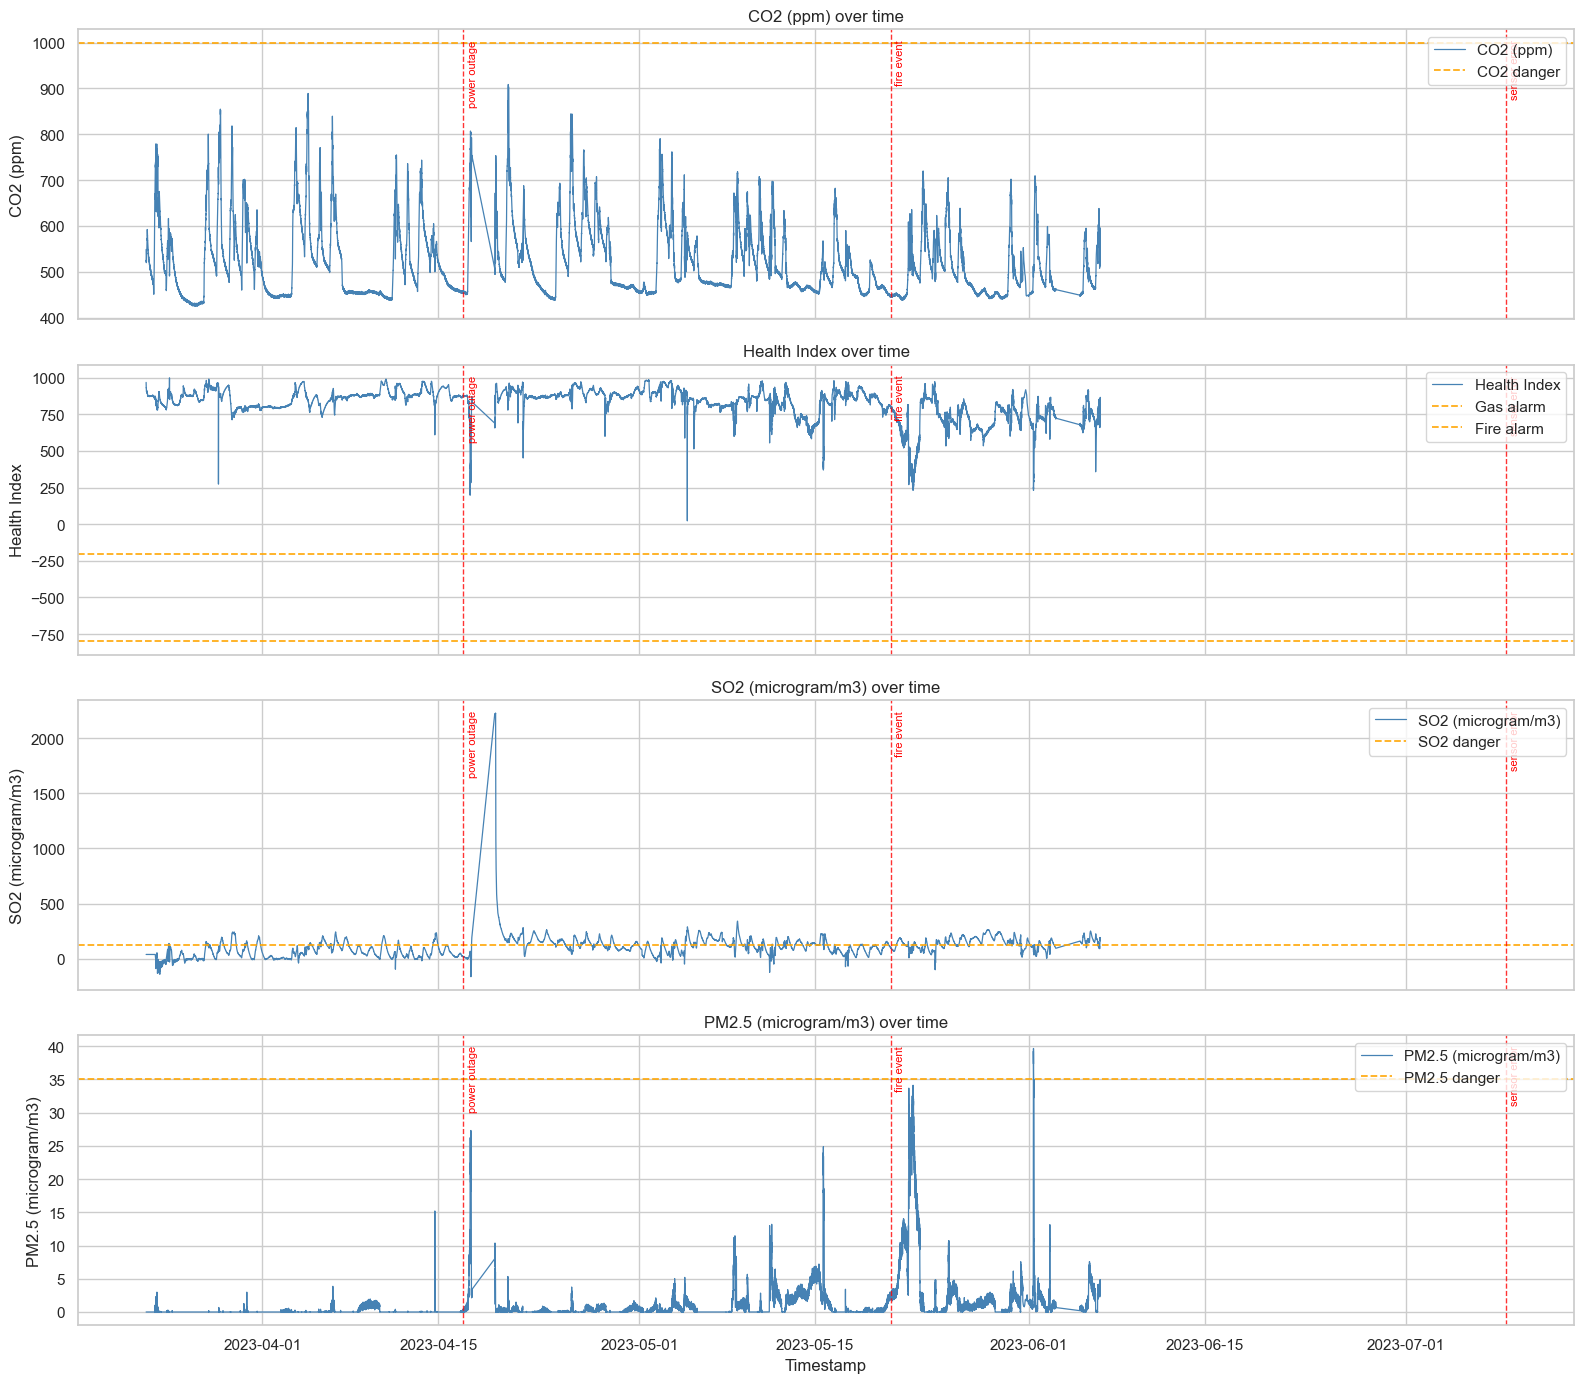

Saved figure: c:\Users\H-Info\Desktop\test02\outputs\figures\time_series.png


In [5]:
# Cell 5: Visualize key sensors over time with anomaly markers and thresholds
event_markers = [
    ('power_outage', pd.to_datetime(ANOMALY_DATES['power_outage'])),
    ('fire_event', pd.to_datetime(ANOMALY_DATES['fire_event'])),
    ('sensor_error', pd.to_datetime(ANOMALY_DATES['sensor_error']))
]

plot_sensors = ['co2', 'health', 'so2', 'pm2_5']
sensor_titles = {
    'co2': 'CO2 (ppm)',
    'health': 'Health Index',
    'so2': 'SO2 (microgram/m3)',
    'pm2_5': 'PM2.5 (microgram/m3)'
}

sensor_thresholds = {
    'co2': [(CO2_DANGER, 'CO2 danger')],
    'health': [(HEALTH_GAS, 'Gas alarm'), (HEALTH_FIRE, 'Fire alarm')],
    'so2': [(SO2_DANGER, 'SO2 danger')],
    'pm2_5': [(PM25_DANGER, 'PM2.5 danger')]
}

fig, axes = plt.subplots(4, 1, sharex=True, figsize=(16, 14))

for ax, sensor in zip(axes, plot_sensors):
    ax.plot(df_lab['timestamp'], df_lab[sensor], color='steelblue', linewidth=0.9, label=sensor_titles[sensor])
    ax.set_ylabel(sensor_titles[sensor])
    ax.set_title(f'{sensor_titles[sensor]} over time')

    for threshold, threshold_label in sensor_thresholds[sensor]:
        ax.axhline(
            y=threshold,
            color='orange',
            linestyle='--',
            linewidth=1.3,
            alpha=0.9,
            label=threshold_label
        )

    for event_name, event_date in event_markers:
        ax.axvline(event_date, color='red', linestyle='--', linewidth=1.0, alpha=0.8)
        ax.annotate(
            event_name.replace('_', ' '),
            xy=(event_date, 0.98),
            xycoords=('data', 'axes fraction'),
            xytext=(3, -3),
            textcoords='offset points',
            color='red',
            fontsize=8,
            rotation=90,
            va='top'
        )

    ax.legend(loc='upper right')

axes[-1].set_xlabel('Timestamp')
plt.tight_layout()

time_series_path = FIG_DIR / 'time_series.png'
fig.savefig(time_series_path, dpi=300, bbox_inches='tight')
plt.show()

print(f'Saved figure: {time_series_path}')

## Phase 3: Graph Construction
This phase normalizes sensor values, builds correlation-based graph structure, defines PyG graph builders, assigns labels, and creates full sparse/full graph datasets.

In [6]:
# Cell 6: Normalize sensor values
df_lab_raw = df_lab.copy()
df_apt_raw = df_apt.copy()

# Fit only on lab, then transform both lab and apartment to simulate deployment
scaler_lab = MinMaxScaler(feature_range=(0, 1), clip=True)

df_lab_norm = df_lab.copy()
df_apt_norm = df_apt.copy()

# Keep raw values for threshold-based labeling later
for col in SENSOR_COLUMNS:
    df_lab_norm[f'raw_{col}'] = df_lab_raw[col].values
    df_apt_norm[f'raw_{col}'] = df_apt_raw[col].values

df_lab_norm[SENSOR_COLUMNS] = scaler_lab.fit_transform(df_lab_raw[SENSOR_COLUMNS])
df_apt_norm[SENSOR_COLUMNS] = scaler_lab.transform(df_apt_raw[SENSOR_COLUMNS])

feature_scaler = scaler_lab

lab_min = df_lab_norm[SENSOR_COLUMNS].min()
lab_max = df_lab_norm[SENSOR_COLUMNS].max()
apt_min = df_apt_norm[SENSOR_COLUMNS].min()
apt_max = df_apt_norm[SENSOR_COLUMNS].max()

range_check = pd.DataFrame({
    'lab_min': lab_min,
    'lab_max': lab_max,
    'apt_min': apt_min,
    'apt_max': apt_max
}).round(6)

display(range_check)
print('Lab in [0,1]:', bool(((lab_min >= 0) & (lab_max <= 1)).all()))
print('Apartment in [0,1]:', bool(((apt_min >= 0) & (apt_max <= 1)).all()))

,lab_min,lab_max,apt_min,apt_max
TypPS,0.0,1.0,0.003643,1.000000
oxygen,0.0,1.0,0.000000,0.985455
pm10,0.0,1.0,0.000000,1.000000
cnt0_5,0.0,1.0,0.002718,1.000000
co,0.0,1.0,0.270968,1.000000
temperature,0.0,1.0,0.505015,1.000000
performance,0.0,1.0,0.000000,1.000000
co2,0.0,1.0,0.000000,1.000000
measuretime,0.0,1.0,0.000000,1.000000
so2,0.0,1.0,0.000000,0.865713


Lab in [0,1]: True
Apartment in [0,1]: True


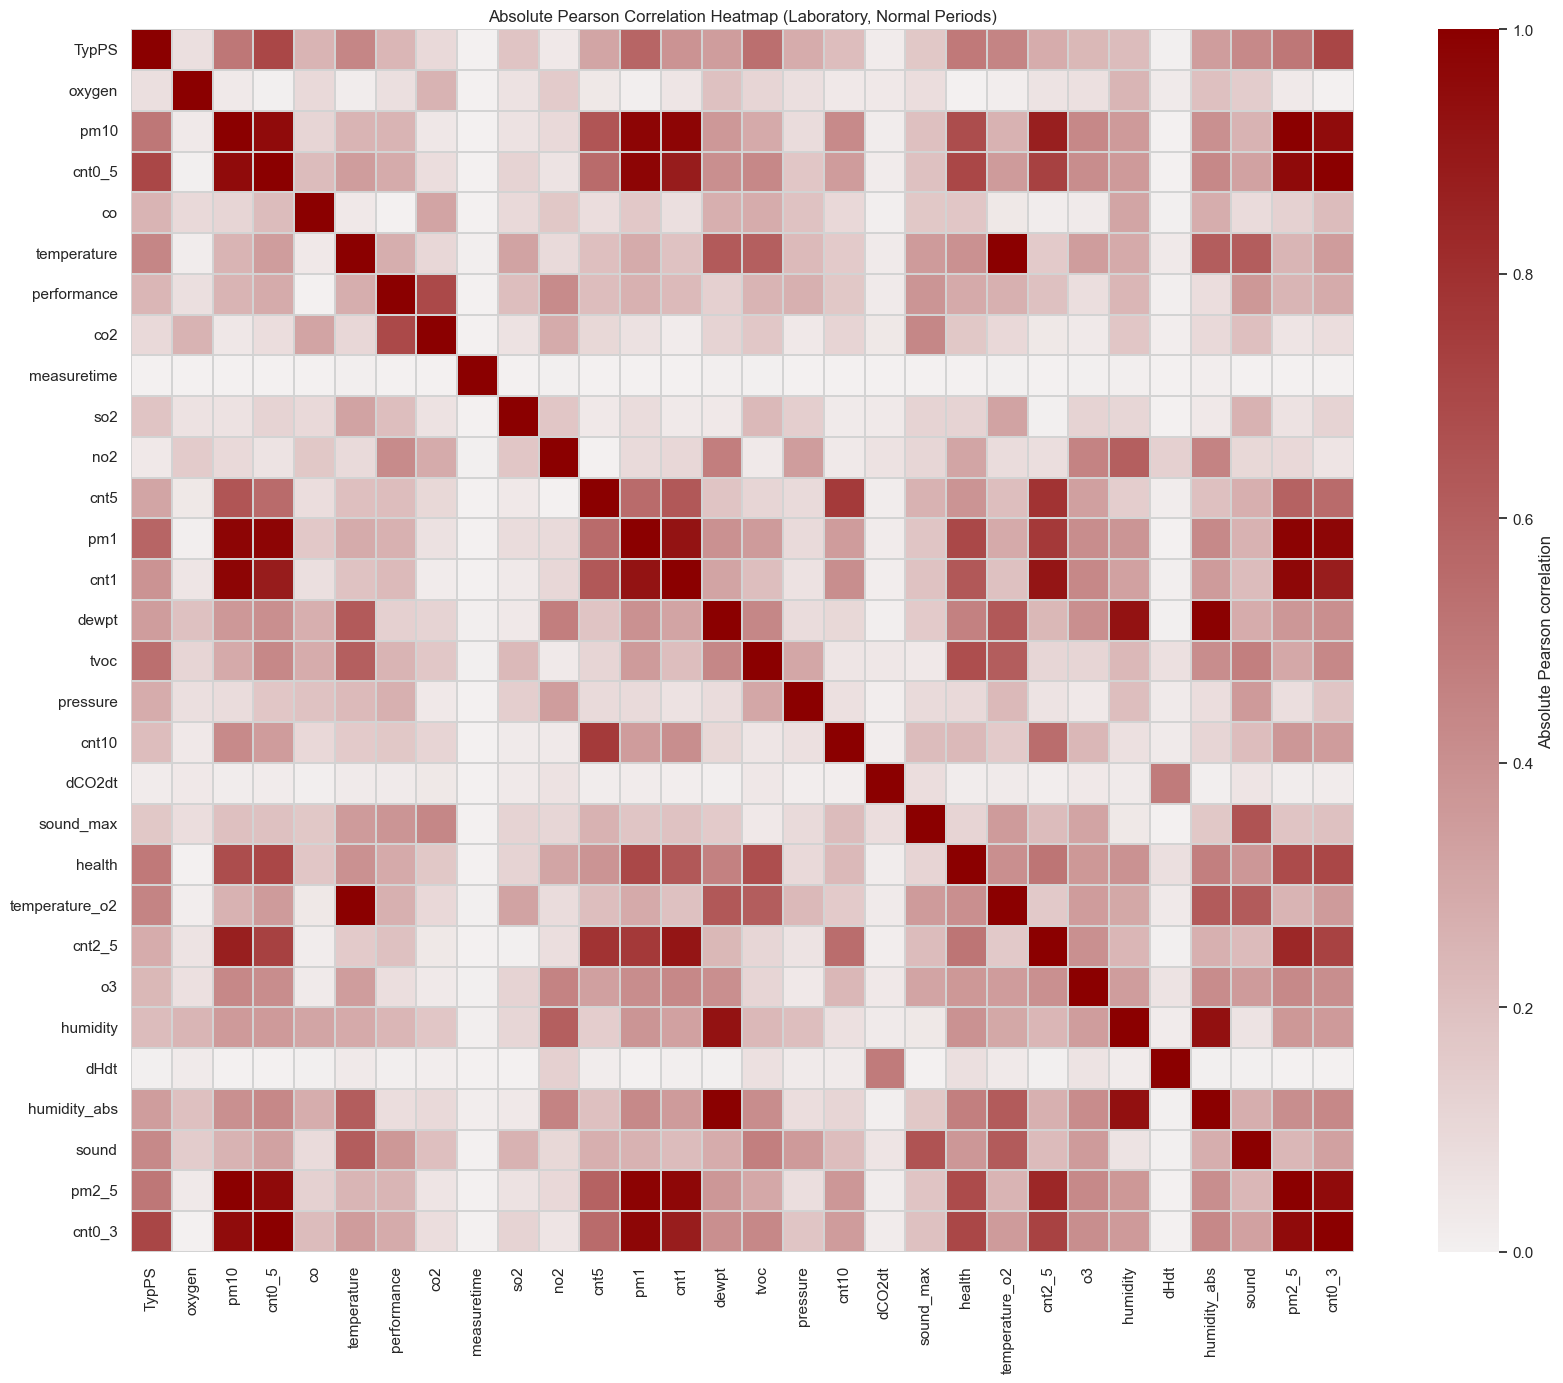

Threshold: 0.5
Number of sparse edges above threshold: 59
Saved figure: c:\Users\H-Info\Desktop\test02\outputs\figures\correlation_heatmap.png


In [7]:
# Cell 7: Compute Pearson correlation matrix from normal lab rows
THRESHOLD = 0.5

normal_lab = df_lab_norm[df_lab_norm['event'] == 'normal'].copy()
corr_matrix = normal_lab[SENSOR_COLUMNS].corr().abs()

fig, ax = plt.subplots(figsize=(18, 14))
heatmap_cmap = sns.light_palette('darkred', as_cmap=True)
sns.heatmap(
    corr_matrix,
    cmap=heatmap_cmap,
    vmin=0,
    vmax=1,
    square=True,
    linewidths=0.3,
    linecolor='lightgray',
    cbar_kws={'label': 'Absolute Pearson correlation'},
    ax=ax
)
ax.set_title('Absolute Pearson Correlation Heatmap (Laboratory, Normal Periods)')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()

corr_heatmap_path = FIG_DIR / 'correlation_heatmap.png'
fig.savefig(corr_heatmap_path, dpi=300, bbox_inches='tight')
plt.show()

upper_triangle_mask = np.triu(np.ones_like(corr_matrix.values, dtype=bool), k=1)
edge_count_sparse = int(((corr_matrix.values > THRESHOLD) & upper_triangle_mask).sum())
print(f'Threshold: {THRESHOLD}')
print(f'Number of sparse edges above threshold: {edge_count_sparse}')
print(f'Saved figure: {corr_heatmap_path}')

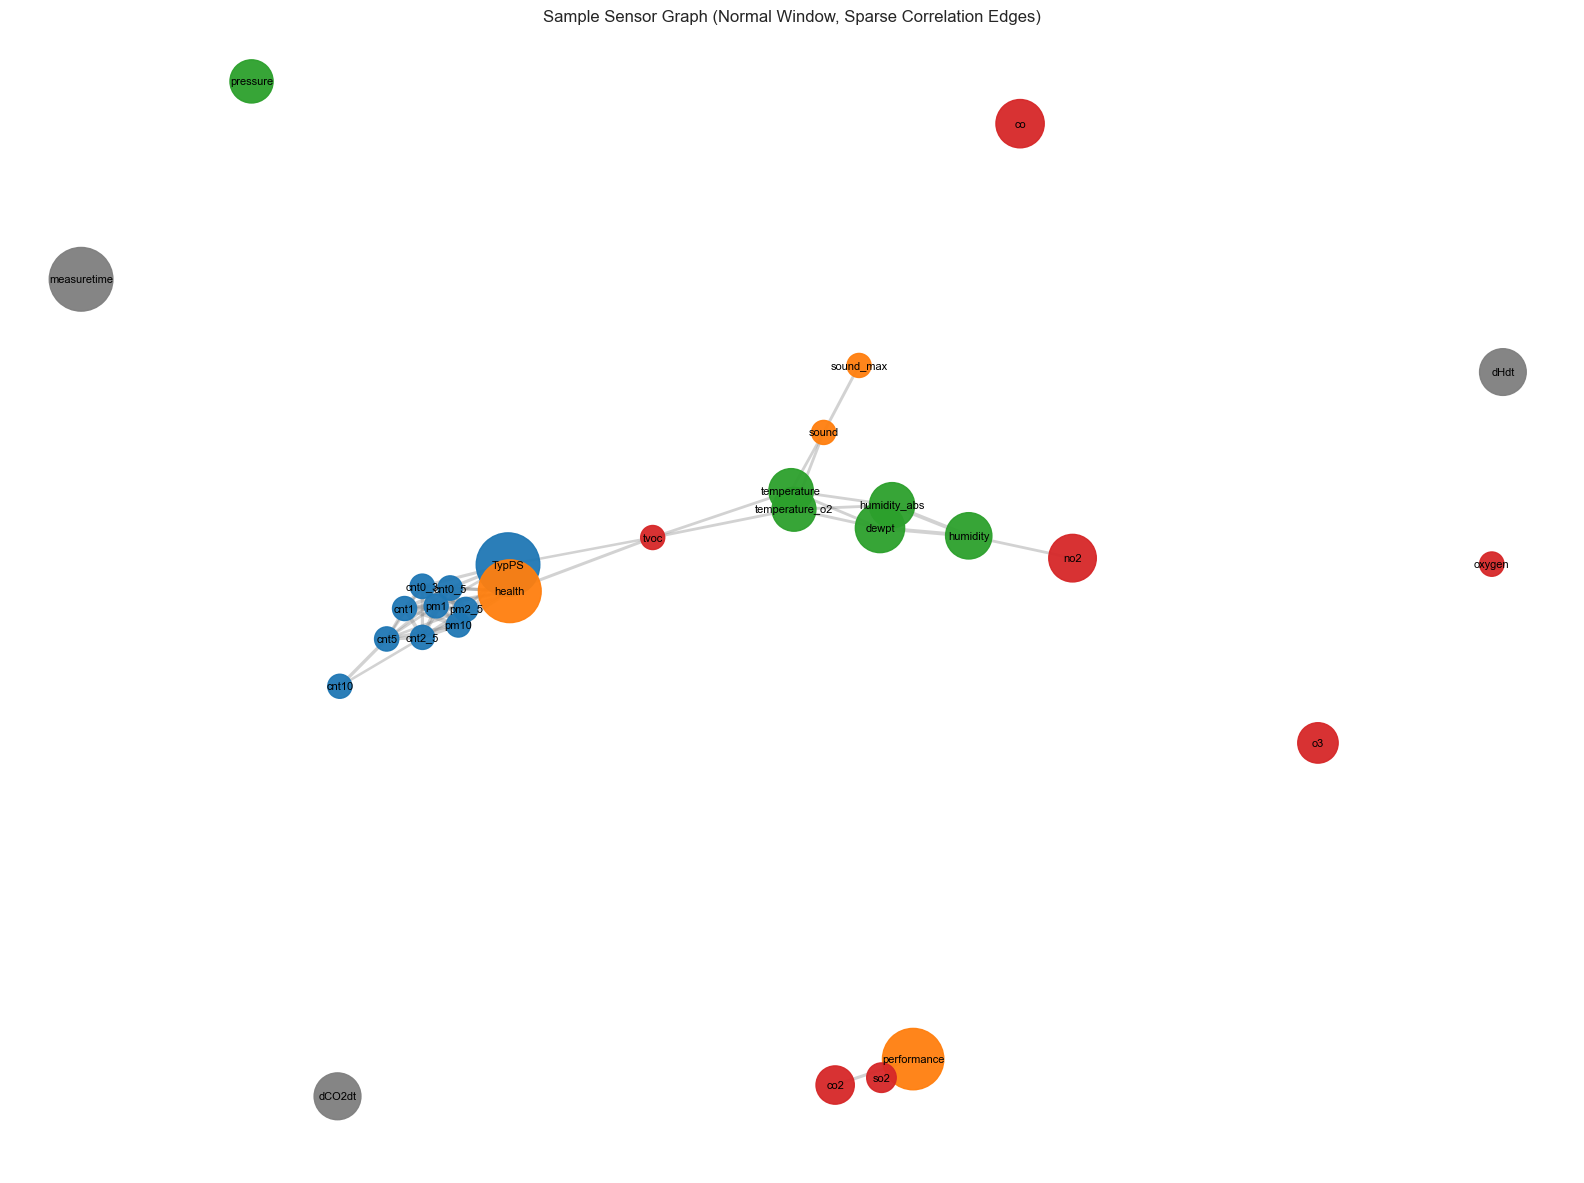

Nodes: 30 | Edges: 59
Saved figure: c:\Users\H-Info\Desktop\test02\outputs\figures\sample_graph.png
Saved graphml: c:\Users\H-Info\Desktop\test02\outputs\graphs\sample_graph.graphml


In [8]:
# Cell 8: Build and visualize one sample graph
def sensor_category(sensor_name):
    gas = {'co', 'co2', 'so2', 'no2', 'o3', 'tvoc', 'oxygen'}
    particle = {'pm1', 'pm2_5', 'pm10', 'TypPS', 'cnt0_3', 'cnt0_5', 'cnt1', 'cnt2_5', 'cnt5', 'cnt10'}
    climate = {'temperature', 'temperature_o2', 'humidity', 'humidity_abs', 'pressure', 'dewpt'}
    composite = {'health', 'performance', 'sound', 'sound_max'}

    if sensor_name in gas:
        return 'gas'
    if sensor_name in particle:
        return 'particle'
    if sensor_name in climate:
        return 'climate'
    if sensor_name in composite:
        return 'composite'
    return 'other'

CATEGORY_COLORS = {
    'gas': '#d62728',
    'particle': '#1f77b4',
    'climate': '#2ca02c',
    'composite': '#ff7f0e',
    'other': '#7f7f7f'
}

def build_nx_graph_from_row(row, corr_matrix, threshold):
    g_nx = nx.Graph()

    for sensor in SENSOR_COLUMNS:
        sensor_val = float(row[sensor])
        category = sensor_category(sensor)
        g_nx.add_node(sensor, value=sensor_val, category=category)

    for i, s_i in enumerate(SENSOR_COLUMNS):
        for j in range(i + 1, len(SENSOR_COLUMNS)):
            s_j = SENSOR_COLUMNS[j]
            corr_ij = float(corr_matrix.iloc[i, j])
            if corr_ij > threshold:
                g_nx.add_edge(s_i, s_j, weight=corr_ij)

    return g_nx

sample_row = normal_lab.iloc[0]
sample_graph = build_nx_graph_from_row(sample_row, corr_matrix, THRESHOLD)

sample_pos = nx.spring_layout(sample_graph, seed=RANDOM_SEED, weight='weight')
sample_node_colors = [CATEGORY_COLORS[sample_graph.nodes[n]['category']] for n in sample_graph.nodes]
sample_node_sizes = [300 + 1800 * sample_graph.nodes[n]['value'] for n in sample_graph.nodes]
sample_edge_widths = [0.5 + 2.5 * sample_graph[u][v]['weight'] for u, v in sample_graph.edges]

fig, ax = plt.subplots(figsize=(16, 12))
nx.draw_networkx_edges(sample_graph, sample_pos, width=sample_edge_widths, alpha=0.35, edge_color='gray', ax=ax)
nx.draw_networkx_nodes(sample_graph, sample_pos, node_size=sample_node_sizes, node_color=sample_node_colors, alpha=0.95, ax=ax)
nx.draw_networkx_labels(sample_graph, sample_pos, font_size=8, font_color='black', ax=ax)
ax.set_title('Sample Sensor Graph (Normal Window, Sparse Correlation Edges)')
ax.axis('off')
plt.tight_layout()

sample_graph_png = FIG_DIR / 'sample_graph.png'
sample_graph_graphml = GRAPH_DIR / 'sample_graph.graphml'
fig.savefig(sample_graph_png, dpi=300, bbox_inches='tight')
nx.write_graphml(sample_graph, sample_graph_graphml)
plt.show()

print(f'Nodes: {sample_graph.number_of_nodes()} | Edges: {sample_graph.number_of_edges()}')
print(f'Saved figure: {sample_graph_png}')
print(f'Saved graphml: {sample_graph_graphml}')

In [9]:
# Cell 9: Define graph-building function for PyTorch Geometric
from torch_geometric.data import Data

def _get_col(window_rows, base_col):
    raw_col = f'raw_{base_col}'
    return raw_col if raw_col in window_rows.columns else base_col

def build_pyg_graph(window_rows, corr_matrix, threshold, fully_connected=False):
    num_nodes = len(SENSOR_COLUMNS)
    sensor_mean = window_rows[SENSOR_COLUMNS].mean().to_numpy(dtype=np.float32)

    # Each node carries the same global window summary vector -> x shape [31, 31]
    x = torch.tensor(np.tile(sensor_mean, (num_nodes, 1)), dtype=torch.float32)

    # Cache static graph structure for speed
    if not hasattr(build_pyg_graph, '_edge_cache'):
        build_pyg_graph._edge_cache = {}

    cache_key = (fully_connected, float(threshold))
    if cache_key not in build_pyg_graph._edge_cache:
        src, dst, wts = [], [], []

        if fully_connected:
            for i in range(num_nodes):
                for j in range(num_nodes):
                    if i == j:
                        continue
                    w = float(corr_matrix.iloc[i, j])
                    src.append(i)
                    dst.append(j)
                    wts.append(w)
        else:
            for i in range(num_nodes):
                for j in range(i + 1, num_nodes):
                    w = float(corr_matrix.iloc[i, j])
                    if w > threshold:
                        src.extend([i, j])
                        dst.extend([j, i])
                        wts.extend([w, w])

        if len(wts) == 0:
            # Safety fallback when threshold is too strict
            for i in range(num_nodes):
                src.append(i)
                dst.append(i)
                wts.append(1.0)

        edge_index = torch.tensor([src, dst], dtype=torch.long)
        edge_attr = torch.tensor(wts, dtype=torch.float32).unsqueeze(1)
        build_pyg_graph._edge_cache[cache_key] = (edge_index, edge_attr)

    edge_index, edge_attr = build_pyg_graph._edge_cache[cache_key]

    # Assign y if label_window exists, otherwise use fallback logic
    if 'label_window' in globals():
        y_value = int(label_window(window_rows))
    else:
        health_col = _get_col(window_rows, 'health')
        co_col = _get_col(window_rows, 'co')
        co2_col = _get_col(window_rows, 'co2')
        pm25_col = _get_col(window_rows, 'pm2_5')
        tvoc_col = _get_col(window_rows, 'tvoc')

        if (window_rows[health_col] == HEALTH_FIRE).any() or (window_rows['event'] == 'fire_event').any():
            y_value = 3
        elif (window_rows[health_col] == HEALTH_GAS).any() or (window_rows[co_col] > CO_DANGER).any():
            y_value = 2
        elif (window_rows[co2_col].mean() > CO2_DANGER) or (window_rows[pm25_col].mean() > PM25_DANGER) or (window_rows[tvoc_col].mean() > VOC_DANGER):
            y_value = 1
        else:
            y_value = 0

    y = torch.tensor([y_value], dtype=torch.long)
    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)

test_window = df_lab_norm.iloc[0:10].copy()
test_graph = build_pyg_graph(test_window, corr_matrix, THRESHOLD, fully_connected=False)
print(test_graph)
print('x shape:', tuple(test_graph.x.shape))
print('edge_index shape:', tuple(test_graph.edge_index.shape))
print('edge_attr shape:', tuple(test_graph.edge_attr.shape))
print('y:', test_graph.y.tolist())

Data(x=[30, 30], edge_index=[2, 118], edge_attr=[118, 1], y=[1])
x shape: (30, 30)
edge_index shape: (2, 118)
edge_attr shape: (118, 1)
y: [0]


In [10]:
# Cell 10: Assign labels to each window
def label_window(window_rows):
    health_col = _get_col(window_rows, 'health')
    co_col = _get_col(window_rows, 'co')
    co2_col = _get_col(window_rows, 'co2')
    pm25_col = _get_col(window_rows, 'pm2_5')
    tvoc_col = _get_col(window_rows, 'tvoc')

    # Priority: fire (3) > gas (2) > polluted (1) > clean (0)
    if (window_rows[health_col] == HEALTH_FIRE).any() or (window_rows['event'] == 'fire_event').any():
        return 3

    if (window_rows[health_col] == HEALTH_GAS).any() or (window_rows[co_col] > CO_DANGER).any():
        return 2

    if (window_rows[co2_col].mean() > CO2_DANGER) or (window_rows[pm25_col].mean() > PM25_DANGER) or (window_rows[tvoc_col].mean() > VOC_DANGER):
        return 1

    return 0

Lab sparse graphs: 10236
Lab full graphs: 10236
Apartment sparse graphs: 2488
Apartment full graphs: 2488


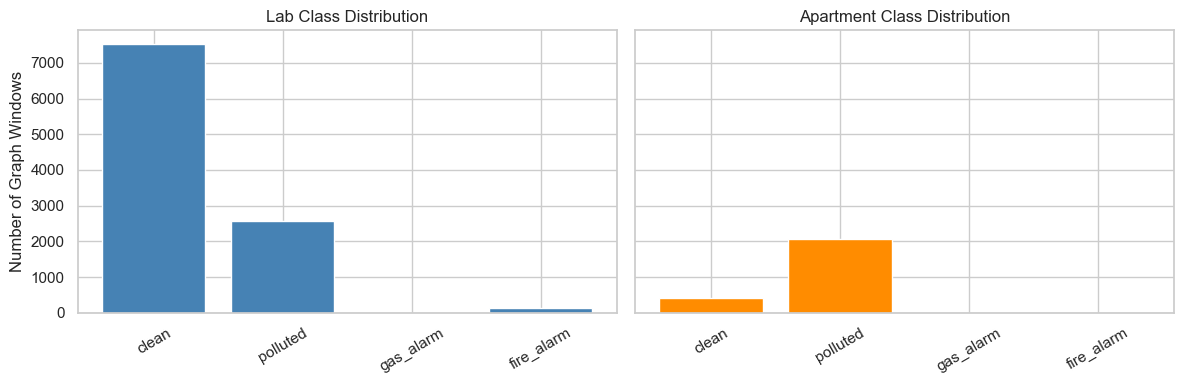

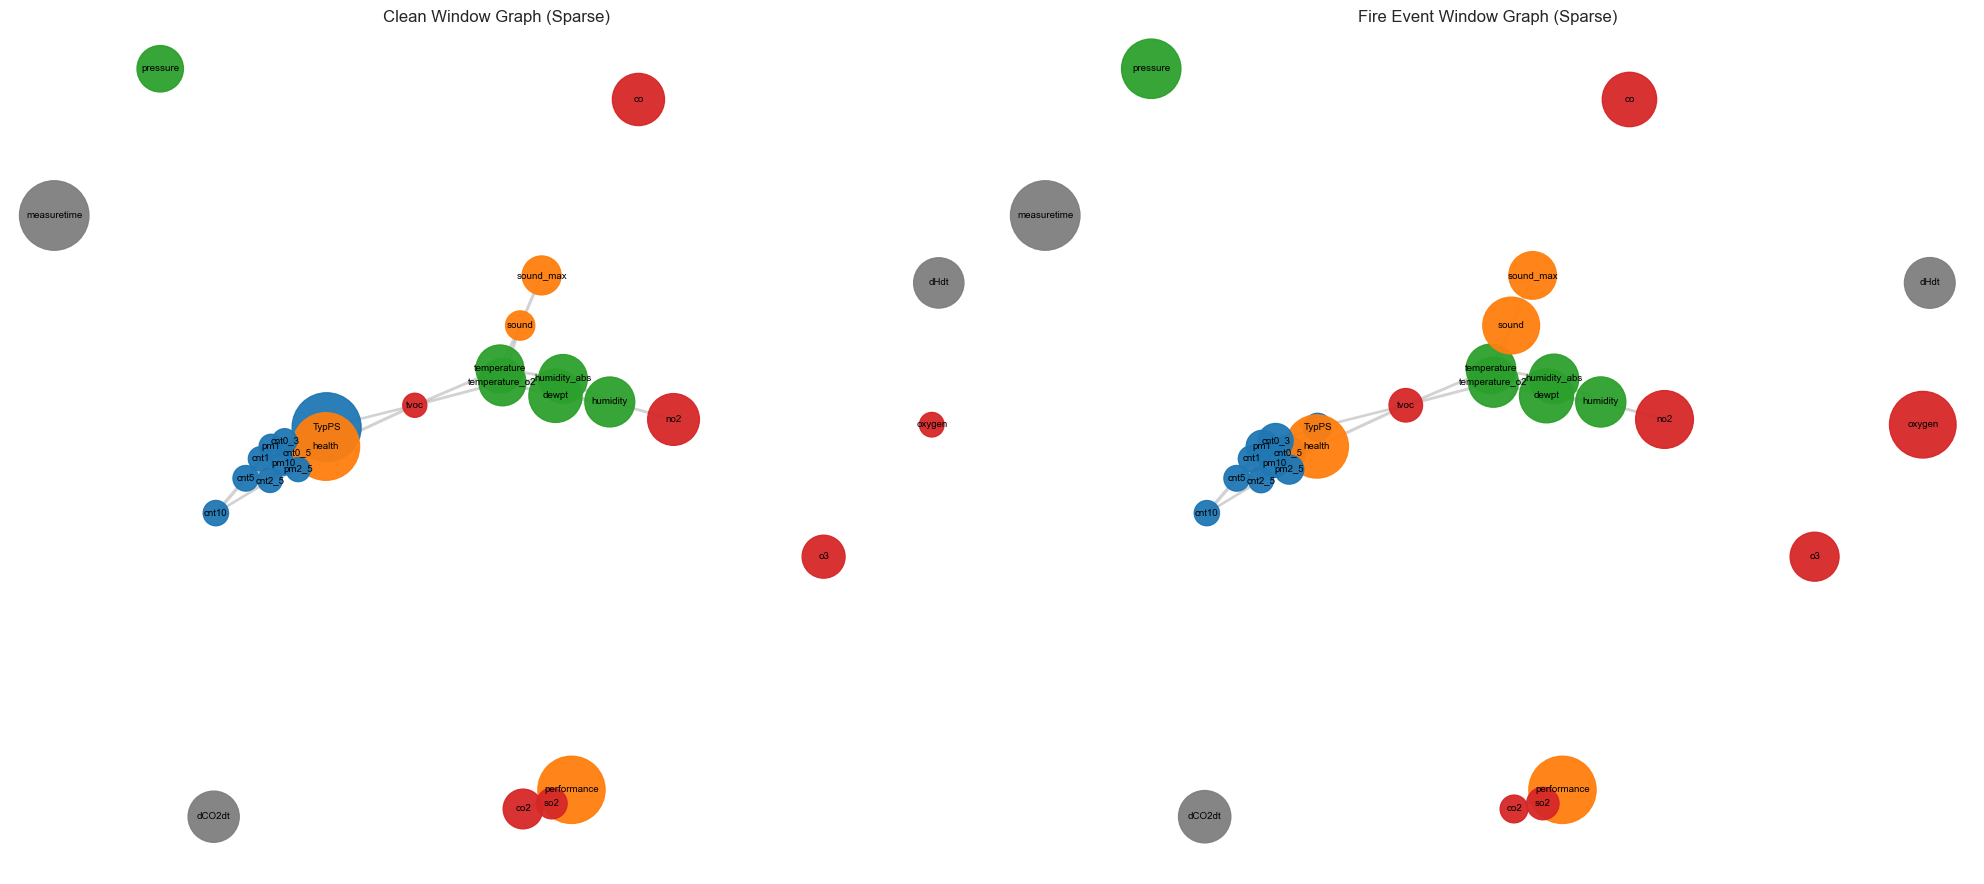

Saved figure: c:\Users\H-Info\Desktop\test02\outputs\figures\clean_vs_fire_graph.png
Saved graphml: c:\Users\H-Info\Desktop\test02\outputs\graphs\clean_graph.graphml
Saved graphml: c:\Users\H-Info\Desktop\test02\outputs\graphs\fire_graph.graphml


In [11]:
# Cell 11: Build full graph datasets and visualize clean vs fire graph
WINDOW_SIZE = 10
STEP = 5

def build_graph_datasets(df_norm, corr_matrix, threshold, window_size=10, step=5):
    graphs_sparse = []
    graphs_full = []
    labels = []

    max_start = len(df_norm) - window_size + 1
    for start in range(0, max_start, step):
        window = df_norm.iloc[start:start + window_size]
        lbl = int(label_window(window))

        g_sparse = build_pyg_graph(window, corr_matrix, threshold, fully_connected=False)
        g_full = build_pyg_graph(window, corr_matrix, threshold, fully_connected=True)

        g_sparse.y = torch.tensor([lbl], dtype=torch.long)
        g_full.y = torch.tensor([lbl], dtype=torch.long)

        graphs_sparse.append(g_sparse)
        graphs_full.append(g_full)
        labels.append(lbl)

    return graphs_sparse, graphs_full, labels

lab_graphs_sparse, lab_graphs_full, lab_labels = build_graph_datasets(
    df_lab_norm, corr_matrix, THRESHOLD, window_size=WINDOW_SIZE, step=STEP
)
apt_graphs_sparse, apt_graphs_full, apt_labels = build_graph_datasets(
    df_apt_norm, corr_matrix, THRESHOLD, window_size=WINDOW_SIZE, step=STEP
)

print('Lab sparse graphs:', len(lab_graphs_sparse))
print('Lab full graphs:', len(lab_graphs_full))
print('Apartment sparse graphs:', len(apt_graphs_sparse))
print('Apartment full graphs:', len(apt_graphs_full))

class_name = {0: 'clean', 1: 'polluted', 2: 'gas_alarm', 3: 'fire_alarm'}
class_order = [0, 1, 2, 3]

lab_dist = pd.Series(lab_labels).value_counts().reindex(class_order, fill_value=0)
apt_dist = pd.Series(apt_labels).value_counts().reindex(class_order, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
axes[0].bar([class_name[c] for c in class_order], lab_dist.values, color='steelblue')
axes[0].set_title('Lab Class Distribution')
axes[0].set_ylabel('Number of Graph Windows')
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar([class_name[c] for c in class_order], apt_dist.values, color='darkorange')
axes[1].set_title('Apartment Class Distribution')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

def pyg_to_networkx(data_obj):
    g_nx = nx.Graph()

    for i, sensor in enumerate(SENSOR_COLUMNS):
        node_val = float(data_obj.x[i, i].item())
        g_nx.add_node(sensor, value=node_val, category=sensor_category(sensor))

    edge_index_np = data_obj.edge_index.cpu().numpy()
    edge_attr_np = data_obj.edge_attr.cpu().numpy().flatten()

    for e in range(edge_index_np.shape[1]):
        u = int(edge_index_np[0, e])
        v = int(edge_index_np[1, e])
        if u == v:
            continue

        su = SENSOR_COLUMNS[u]
        sv = SENSOR_COLUMNS[v]
        w = float(edge_attr_np[e])

        if g_nx.has_edge(su, sv):
            if w > g_nx[su][sv]['weight']:
                g_nx[su][sv]['weight'] = w
        else:
            g_nx.add_edge(su, sv, weight=w)

    return g_nx

def draw_sensor_graph(ax, g_nx, title):
    pos = nx.spring_layout(g_nx, seed=RANDOM_SEED, weight='weight')
    node_colors = [CATEGORY_COLORS[g_nx.nodes[n]['category']] for n in g_nx.nodes]
    node_sizes = [300 + 2200 * g_nx.nodes[n]['value'] for n in g_nx.nodes]
    edge_widths = [0.6 + 2.4 * g_nx[u][v]['weight'] for u, v in g_nx.edges]

    nx.draw_networkx_edges(g_nx, pos, width=edge_widths, alpha=0.35, edge_color='gray', ax=ax)
    nx.draw_networkx_nodes(g_nx, pos, node_size=node_sizes, node_color=node_colors, alpha=0.95, ax=ax)
    nx.draw_networkx_labels(g_nx, pos, font_size=7, font_color='black', ax=ax)
    ax.set_title(title)
    ax.axis('off')

clean_indices = [i for i, y in enumerate(lab_labels) if y == 0]
fire_indices = [i for i, y in enumerate(lab_labels) if y == 3]

if len(clean_indices) == 0 or len(fire_indices) == 0:
    print('Warning: could not find both clean and fire windows in lab graphs.')
else:
    clean_idx = clean_indices[0]
    fire_idx = fire_indices[0]

    clean_g = pyg_to_networkx(lab_graphs_sparse[clean_idx])
    fire_g = pyg_to_networkx(lab_graphs_sparse[fire_idx])

    fig, axes = plt.subplots(1, 2, figsize=(20, 9))
    draw_sensor_graph(axes[0], clean_g, 'Clean Window Graph (Sparse)')
    draw_sensor_graph(axes[1], fire_g, 'Fire Event Window Graph (Sparse)')
    plt.tight_layout()

    clean_vs_fire_path = FIG_DIR / 'clean_vs_fire_graph.png'
    fig.savefig(clean_vs_fire_path, dpi=300, bbox_inches='tight')
    plt.show()

    clean_graphml_path = GRAPH_DIR / 'clean_graph.graphml'
    fire_graphml_path = GRAPH_DIR / 'fire_graph.graphml'
    nx.write_graphml(clean_g, clean_graphml_path)
    nx.write_graphml(fire_g, fire_graphml_path)

    print(f'Saved figure: {clean_vs_fire_path}')
    print(f'Saved graphml: {clean_graphml_path}')
    print(f'Saved graphml: {fire_graphml_path}')

## Phase 4: Train / Validation / Test Split
This phase performs stratified splitting on laboratory graphs, keeps apartment graphs fully separate, and builds PyG DataLoaders.

In [12]:
# Cell 12: Split data into train / validation / test (stratified, aligned indices)
from torch_geometric.loader import DataLoader

BATCH_SIZE = 32

num_lab_graphs = len(lab_graphs_sparse)
all_indices = np.arange(num_lab_graphs)
all_labels = np.array(lab_labels, dtype=int)

# First split: train 70%, temp 30%
train_idx, temp_idx, y_train, y_temp = train_test_split(
    all_indices,
    all_labels,
    test_size=0.30,
    random_state=RANDOM_SEED,
    stratify=all_labels
 )

# Second split: temp -> val 15%, test 15% (50/50 of temp)
val_idx, test_idx, y_val, y_test = train_test_split(
    temp_idx,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_SEED,
    stratify=y_temp
 )

# Build sparse splits
train_graphs_sparse = [lab_graphs_sparse[i] for i in train_idx]
val_graphs_sparse = [lab_graphs_sparse[i] for i in val_idx]
test_graphs_sparse = [lab_graphs_sparse[i] for i in test_idx]

# Build full splits using identical indices for fair comparison
train_graphs_full = [lab_graphs_full[i] for i in train_idx]
val_graphs_full = [lab_graphs_full[i] for i in val_idx]
test_graphs_full = [lab_graphs_full[i] for i in test_idx]

# Apartment stays untouched for cross-environment evaluation
apt_graphs_sparse_holdout = apt_graphs_sparse
apt_graphs_full_holdout = apt_graphs_full

# PyG DataLoaders
train_loader_sparse = DataLoader(train_graphs_sparse, batch_size=BATCH_SIZE, shuffle=True)
val_loader_sparse = DataLoader(val_graphs_sparse, batch_size=BATCH_SIZE, shuffle=False)
test_loader_sparse = DataLoader(test_graphs_sparse, batch_size=BATCH_SIZE, shuffle=False)

train_loader_full = DataLoader(train_graphs_full, batch_size=BATCH_SIZE, shuffle=True)
val_loader_full = DataLoader(val_graphs_full, batch_size=BATCH_SIZE, shuffle=False)
test_loader_full = DataLoader(test_graphs_full, batch_size=BATCH_SIZE, shuffle=False)

def split_distribution(labels_array):
    ser = pd.Series(labels_array).value_counts().reindex([0, 1, 2, 3], fill_value=0)
    ser.index = ['clean(0)', 'polluted(1)', 'gas_alarm(2)', 'fire_alarm(3)']
    return ser

train_dist = split_distribution(y_train)
val_dist = split_distribution(y_val)
test_dist = split_distribution(y_test)

print('Split sizes (sparse/full share identical indices):')
print(f'Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}')

print('\nClass distribution - Train:')
display(train_dist.to_frame('count'))
print('Class distribution - Validation:')
display(val_dist.to_frame('count'))
print('Class distribution - Test:')
display(test_dist.to_frame('count'))

print('\nApartment holdout graphs (untouched):')
print(f'Sparse: {len(apt_graphs_sparse_holdout)} | Full: {len(apt_graphs_full_holdout)}')

fire_train = int(train_dist.loc['fire_alarm(3)'])
fire_val = int(val_dist.loc['fire_alarm(3)'])
fire_test = int(test_dist.loc['fire_alarm(3)'])

print('\nFire alarm class presence check:')
print(f'Train fire graphs: {fire_train}')
print(f'Validation fire graphs: {fire_val}')
print(f'Test fire graphs: {fire_test}')

assert fire_train > 0 and fire_val > 0 and fire_test > 0, (
    'Fire alarm class missing in one or more splits. Stratification failed for class 3.'
)

print('\nSplit check passed: class 3 exists in train/val/test.')
print('Reminder: test set remains untouched for training/tuning.')

Split sizes (sparse/full share identical indices):
Train: 7165 | Val: 1535 | Test: 1536

Class distribution - Train:


,count
clean(0),5272
polluted(1),1791
gas_alarm(2),0
fire_alarm(3),102


Class distribution - Validation:


,count
clean(0),1130
polluted(1),383
gas_alarm(2),0
fire_alarm(3),22


Class distribution - Test:


,count
clean(0),1130
polluted(1),384
gas_alarm(2),0
fire_alarm(3),22



Apartment holdout graphs (untouched):
Sparse: 2488 | Full: 2488

Fire alarm class presence check:
Train fire graphs: 102
Validation fire graphs: 22
Test fire graphs: 22

Split check passed: class 3 exists in train/val/test.
Reminder: test set remains untouched for training/tuning.


## Phase 5: GCN Model
This phase defines, trains, and evaluates the baseline GCN model using sparse graphs only.

In [13]:
# Cell 13: Define GCN architecture
from torch_geometric.nn import GCNConv, global_mean_pool
import torch.nn.functional as F

NUM_FEATURES = int(lab_graphs_sparse[0].x.shape[1])
NUM_CLASSES = 4
GCN_IN_CHANNELS = 31
GCN_HIDDEN = 64

if NUM_FEATURES != GCN_IN_CHANNELS:
    print(f'Note: detected graph feature dimension is {NUM_FEATURES}. Using this for runtime compatibility.')

class GCNModel(torch.nn.Module):
    def __init__(self, in_channels=GCN_IN_CHANNELS, hidden_channels=GCN_HIDDEN, num_classes=NUM_CLASSES):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.fc = torch.nn.Linear(hidden_channels, num_classes)

    def forward(self, x, edge_index, batch, edge_attr=None):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = global_mean_pool(x, batch)
        out = self.fc(x)
        return out

gcn_model = GCNModel(in_channels=NUM_FEATURES, hidden_channels=GCN_HIDDEN, num_classes=NUM_CLASSES).to(DEVICE)

total_params = sum(p.numel() for p in gcn_model.parameters() if p.requires_grad)
print(gcn_model)
print(f'Total trainable parameters: {total_params}')

Note: detected graph feature dimension is 30. Using this for runtime compatibility.
GCNModel(
  (conv1): GCNConv(30, 64)
  (conv2): GCNConv(64, 64)
  (fc): Linear(in_features=64, out_features=4, bias=True)
)
Total trainable parameters: 6404


Epoch 001 | Train loss: 0.50823 | Val acc: 0.8886
Epoch 010 | Train loss: 0.06405 | Val acc: 0.9870
Epoch 020 | Train loss: 0.03894 | Val acc: 0.9941
Epoch 030 | Train loss: 0.02824 | Val acc: 0.9987
Epoch 040 | Train loss: 0.01865 | Val acc: 0.9974
Epoch 050 | Train loss: 0.01978 | Val acc: 0.9961
Early stopping at epoch 50 (no val improvement for 20 epochs).


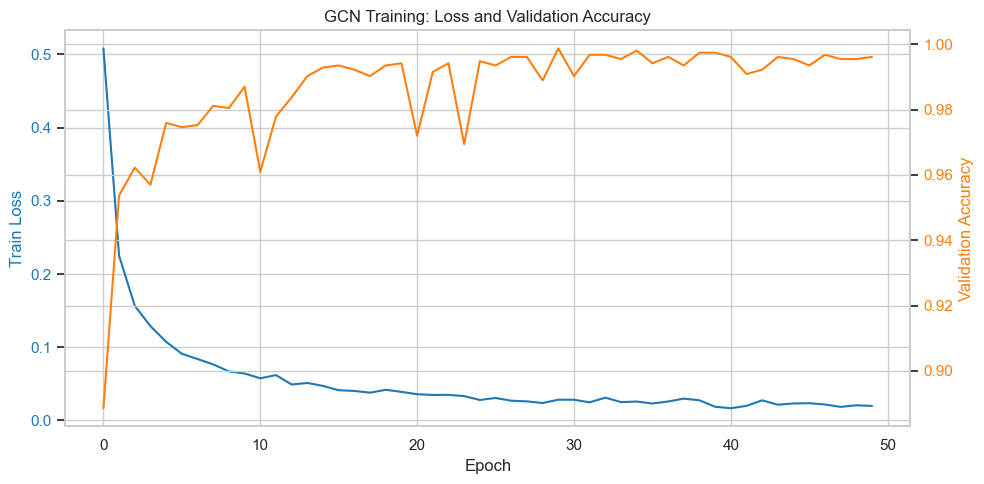

Best validation accuracy: 0.9987 at epoch 30
Saved best model: c:\Users\H-Info\Desktop\test02\outputs\models\gcn_best.pt
Saved training curve: c:\Users\H-Info\Desktop\test02\outputs\figures\gcn_training.png


In [14]:
# Cell 14: Train GCN
from torch.optim import Adam

def evaluate_accuracy(model, loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            logits = model(batch.x, batch.edge_index, batch.batch, batch.edge_attr)
            preds = logits.argmax(dim=1)
            target = batch.y.view(-1)
            correct += int((preds == target).sum().item())
            total += int(target.numel())
    return correct / total if total > 0 else 0.0

gcn_model = GCNModel(in_channels=NUM_FEATURES, hidden_channels=GCN_HIDDEN, num_classes=NUM_CLASSES).to(DEVICE)
gcn_optimizer = Adam(gcn_model.parameters(), lr=0.001)
gcn_criterion = torch.nn.CrossEntropyLoss()

GCN_MAX_EPOCHS = 100
GCN_EARLY_STOPPING_PATIENCE = 20
gcn_train_loss = []
gcn_val_accuracy = []

gcn_best_val_acc = -1.0
gcn_best_epoch = 0
epochs_without_improvement = 0
gcn_best_path = MODEL_DIR / 'gcn_best.pt'

for epoch in range(1, GCN_MAX_EPOCHS + 1):
    gcn_model.train()
    epoch_loss_sum = 0.0
    epoch_graph_count = 0

    for batch in train_loader_sparse:
        batch = batch.to(DEVICE)
        gcn_optimizer.zero_grad()

        logits = gcn_model(batch.x, batch.edge_index, batch.batch, batch.edge_attr)
        target = batch.y.view(-1)
        loss = gcn_criterion(logits, target)

        loss.backward()
        gcn_optimizer.step()

        batch_size = int(target.numel())
        epoch_loss_sum += float(loss.item()) * batch_size
        epoch_graph_count += batch_size

    avg_train_loss = epoch_loss_sum / max(epoch_graph_count, 1)
    val_acc = evaluate_accuracy(gcn_model, val_loader_sparse, DEVICE)

    gcn_train_loss.append(avg_train_loss)
    gcn_val_accuracy.append(val_acc)

    if val_acc > gcn_best_val_acc:
        gcn_best_val_acc = val_acc
        gcn_best_epoch = epoch
        epochs_without_improvement = 0
        torch.save(gcn_model.state_dict(), gcn_best_path)
    else:
        epochs_without_improvement += 1

    if epoch == 1 or epoch % 10 == 0:
        print(f'Epoch {epoch:03d} | Train loss: {avg_train_loss:.5f} | Val acc: {val_acc:.4f}')

    if epochs_without_improvement >= GCN_EARLY_STOPPING_PATIENCE:
        print(f'Early stopping at epoch {epoch} (no val improvement for {GCN_EARLY_STOPPING_PATIENCE} epochs).')
        break

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(gcn_train_loss, color='tab:blue', label='Train Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Train Loss', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.plot(gcn_val_accuracy, color='tab:orange', label='Validation Accuracy')
ax2.set_ylabel('Validation Accuracy', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

ax1.set_title('GCN Training: Loss and Validation Accuracy')
fig.tight_layout()

gcn_training_plot_path = FIG_DIR / 'gcn_training.png'
fig.savefig(gcn_training_plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f'Best validation accuracy: {gcn_best_val_acc:.4f} at epoch {gcn_best_epoch}')
print(f'Saved best model: {gcn_best_path}')
print(f'Saved training curve: {gcn_training_plot_path}')

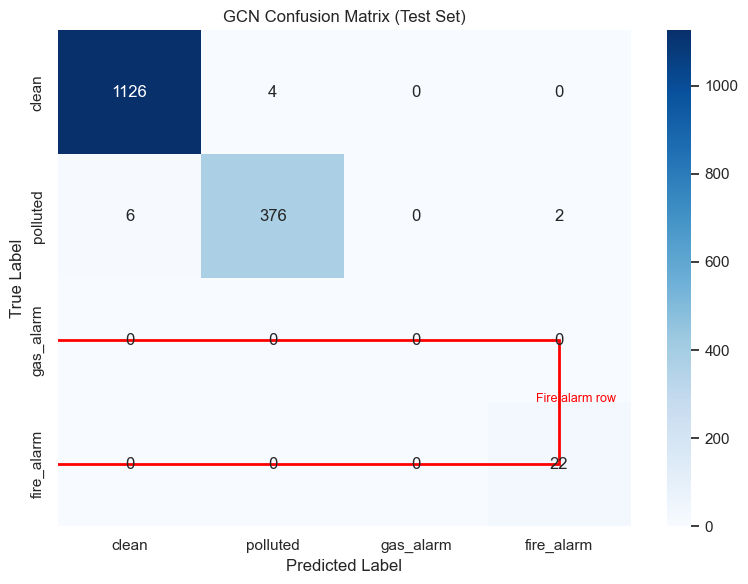

GCN test accuracy: 0.9922

Per-class metrics:
clean      | Precision: 0.9947 | Recall: 0.9965 | F1: 0.9956 | Support: 1130
polluted   | Precision: 0.9895 | Recall: 0.9792 | F1: 0.9843 | Support: 384
gas_alarm  | Precision: 0.0000 | Recall: 0.0000 | F1: 0.0000 | Support: 0
fire_alarm | Precision: 0.9167 | Recall: 1.0000 | F1: 0.9565 | Support: 22

Fire alarm recall (most critical): 1.0000
Saved confusion matrix: c:\Users\H-Info\Desktop\test02\outputs\figures\gcn_confusion.png

Classification report:

              precision    recall  f1-score   support

       clean       0.99      1.00      1.00      1130
    polluted       0.99      0.98      0.98       384
   gas_alarm       0.00      0.00      0.00         0
  fire_alarm       0.92      1.00      0.96        22

    accuracy                           0.99      1536
   macro avg       0.73      0.74      0.73      1536
weighted avg       0.99      0.99      0.99      1536



In [16]:
# Cell 15: Evaluate GCN on test set
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
from matplotlib.patches import Rectangle

gcn_best_model = GCNModel(in_channels=NUM_FEATURES, hidden_channels=GCN_HIDDEN, num_classes=NUM_CLASSES).to(DEVICE)
gcn_best_model.load_state_dict(torch.load(gcn_best_path, map_location=DEVICE))
gcn_best_model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for batch in test_loader_sparse:
        batch = batch.to(DEVICE)
        logits = gcn_best_model(batch.x, batch.edge_index, batch.batch, batch.edge_attr)
        preds = logits.argmax(dim=1).cpu().numpy().tolist()
        labels = batch.y.view(-1).cpu().numpy().tolist()
        y_pred.extend(preds)
        y_true.extend(labels)

class_indices = [0, 1, 2, 3]
class_names = ['clean', 'polluted', 'gas_alarm', 'fire_alarm']

gcn_test_accuracy = accuracy_score(y_true, y_pred)
precision, recall, f1, support = precision_recall_fscore_support(
    y_true, y_pred, labels=class_indices, zero_division=0
)

gcn_confusion = confusion_matrix(y_true, y_pred, labels=class_indices)
gcn_report = classification_report(
    y_true,
    y_pred,
    labels=class_indices,
    target_names=class_names,
    zero_division=0
 )

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    gcn_confusion,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    ax=ax
)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('GCN Confusion Matrix (Test Set)')

fire_row = 3
ax.add_patch(Rectangle((-0.5, fire_row - 0.5), len(class_names), 1, fill=False, edgecolor='red', lw=2))
ax.text(len(class_names) - 0.1, fire_row + 0.02, 'Fire alarm row', color='red', ha='right', va='bottom', fontsize=9)
plt.tight_layout()

gcn_confusion_path = FIG_DIR / 'gcn_confusion.png'
fig.savefig(gcn_confusion_path, dpi=300, bbox_inches='tight')
plt.show()

gcn_results = {
    'best_val_accuracy': float(gcn_best_val_acc),
    'best_epoch': int(gcn_best_epoch),
    'test_accuracy': float(gcn_test_accuracy),
    'precision_per_class': {class_names[i]: float(precision[i]) for i in range(len(class_names))},
    'recall_per_class': {class_names[i]: float(recall[i]) for i in range(len(class_names))},
    'f1_per_class': {class_names[i]: float(f1[i]) for i in range(len(class_names))},
    'support_per_class': {class_names[i]: int(support[i]) for i in range(len(class_names))},
    'confusion_matrix': gcn_confusion.tolist(),
    'classification_report': gcn_report
}

print(f'GCN test accuracy: {gcn_test_accuracy:.4f}')
print('\nPer-class metrics:')
for i, cls_name in enumerate(class_names):
    print(
        f'{cls_name:10s} | Precision: {precision[i]:.4f} | Recall: {recall[i]:.4f} | F1: {f1[i]:.4f} | Support: {support[i]}'
    )

print('\nFire alarm recall (most critical):', f"{gcn_results['recall_per_class']['fire_alarm']:.4f}")
print(f'Saved confusion matrix: {gcn_confusion_path}')
print('\nClassification report:\n')
print(gcn_report)

## Phase 6: GIN Model
This phase defines, trains, and evaluates the GIN model on the same sparse graph splits used by GCN.

In [17]:
# Cell 21: Define GIN architecture
from torch_geometric.nn import GINConv, global_add_pool

GIN_HIDDEN = 64

class GINModel(torch.nn.Module):
    def __init__(self, in_channels=NUM_FEATURES, hidden_channels=GIN_HIDDEN, num_classes=NUM_CLASSES):
        super().__init__()

        self.conv1 = GINConv(
            torch.nn.Sequential(
                torch.nn.Linear(in_channels, hidden_channels),
                torch.nn.BatchNorm1d(hidden_channels),
                torch.nn.ReLU(),
                torch.nn.Linear(hidden_channels, hidden_channels),
                torch.nn.ReLU(),
            )
        )

        self.conv2 = GINConv(
            torch.nn.Sequential(
                torch.nn.Linear(hidden_channels, hidden_channels),
                torch.nn.BatchNorm1d(hidden_channels),
                torch.nn.ReLU(),
                torch.nn.Linear(hidden_channels, hidden_channels),
                torch.nn.ReLU(),
            )
        )

        self.fc = torch.nn.Linear(hidden_channels, num_classes)

    def forward(self, x, edge_index, batch, edge_attr=None):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = global_add_pool(x, batch)
        x = F.dropout(x, p=0.5, training=self.training)
        out = self.fc(x)
        return out

gin_model = GINModel(in_channels=NUM_FEATURES, hidden_channels=GIN_HIDDEN, num_classes=NUM_CLASSES).to(DEVICE)

gin_total_params = sum(p.numel() for p in gin_model.parameters() if p.requires_grad)
print(gin_model)
print(f'Total trainable parameters: {gin_total_params}')

GINModel(
  (conv1): GINConv(nn=Sequential(
    (0): Linear(in_features=30, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): ReLU()
  ))
  (conv2): GINConv(nn=Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): ReLU()
  ))
  (fc): Linear(in_features=64, out_features=4, bias=True)
)
Total trainable parameters: 14980


Epoch 001 | Train loss: 0.43338 | Val acc: 0.9707
Epoch 010 | Train loss: 0.05405 | Val acc: 0.9453
Epoch 020 | Train loss: 0.04351 | Val acc: 0.9857
Early stopping at epoch 29 (no val improvement for 20 epochs).


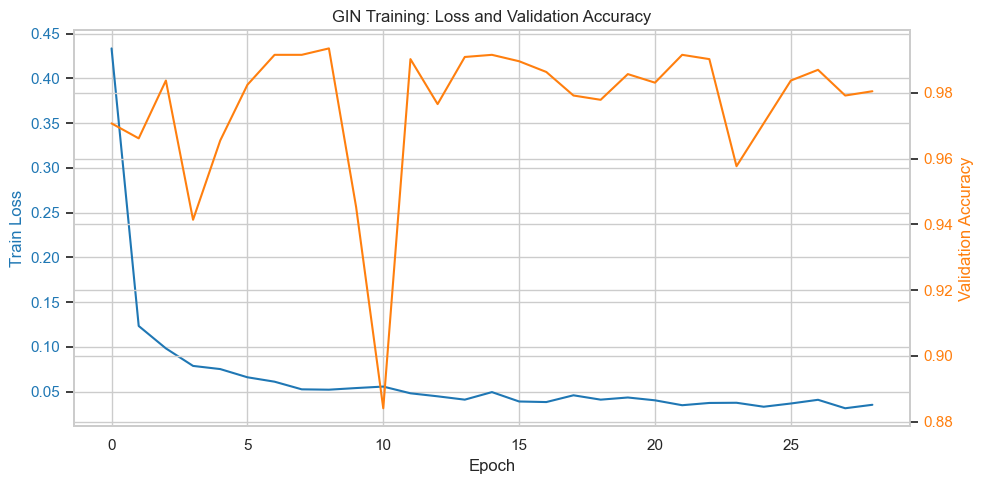

Best validation accuracy: 0.9935 at epoch 9
Saved best model: c:\Users\H-Info\Desktop\test02\outputs\models\gin_best.pt
Saved training curve: c:\Users\H-Info\Desktop\test02\outputs\figures\gin_training.png


In [18]:
# Cell 22: Train GIN
gin_model = GINModel(in_channels=NUM_FEATURES, hidden_channels=GIN_HIDDEN, num_classes=NUM_CLASSES).to(DEVICE)
gin_optimizer = Adam(gin_model.parameters(), lr=0.001)
gin_criterion = torch.nn.CrossEntropyLoss()

GIN_MAX_EPOCHS = 100
GIN_EARLY_STOPPING_PATIENCE = 20
gin_train_loss = []
gin_val_accuracy = []

gin_best_val_acc = -1.0
gin_best_epoch = 0
gin_epochs_without_improvement = 0
gin_best_path = MODEL_DIR / 'gin_best.pt'

for epoch in range(1, GIN_MAX_EPOCHS + 1):
    gin_model.train()
    epoch_loss_sum = 0.0
    epoch_graph_count = 0

    for batch in train_loader_sparse:
        batch = batch.to(DEVICE)
        gin_optimizer.zero_grad()

        logits = gin_model(batch.x, batch.edge_index, batch.batch, batch.edge_attr)
        target = batch.y.view(-1)
        loss = gin_criterion(logits, target)

        loss.backward()
        gin_optimizer.step()

        batch_size = int(target.numel())
        epoch_loss_sum += float(loss.item()) * batch_size
        epoch_graph_count += batch_size

    avg_train_loss = epoch_loss_sum / max(epoch_graph_count, 1)
    val_acc = evaluate_accuracy(gin_model, val_loader_sparse, DEVICE)

    gin_train_loss.append(avg_train_loss)
    gin_val_accuracy.append(val_acc)

    if val_acc > gin_best_val_acc:
        gin_best_val_acc = val_acc
        gin_best_epoch = epoch
        gin_epochs_without_improvement = 0
        torch.save(gin_model.state_dict(), gin_best_path)
    else:
        gin_epochs_without_improvement += 1

    if epoch == 1 or epoch % 10 == 0:
        print(f'Epoch {epoch:03d} | Train loss: {avg_train_loss:.5f} | Val acc: {val_acc:.4f}')

    if gin_epochs_without_improvement >= GIN_EARLY_STOPPING_PATIENCE:
        print(f'Early stopping at epoch {epoch} (no val improvement for {GIN_EARLY_STOPPING_PATIENCE} epochs).')
        break

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(gin_train_loss, color='tab:blue', label='Train Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Train Loss', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.plot(gin_val_accuracy, color='tab:orange', label='Validation Accuracy')
ax2.set_ylabel('Validation Accuracy', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

ax1.set_title('GIN Training: Loss and Validation Accuracy')
fig.tight_layout()

gin_training_plot_path = FIG_DIR / 'gin_training.png'
fig.savefig(gin_training_plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f'Best validation accuracy: {gin_best_val_acc:.4f} at epoch {gin_best_epoch}')
print(f'Saved best model: {gin_best_path}')
print(f'Saved training curve: {gin_training_plot_path}')

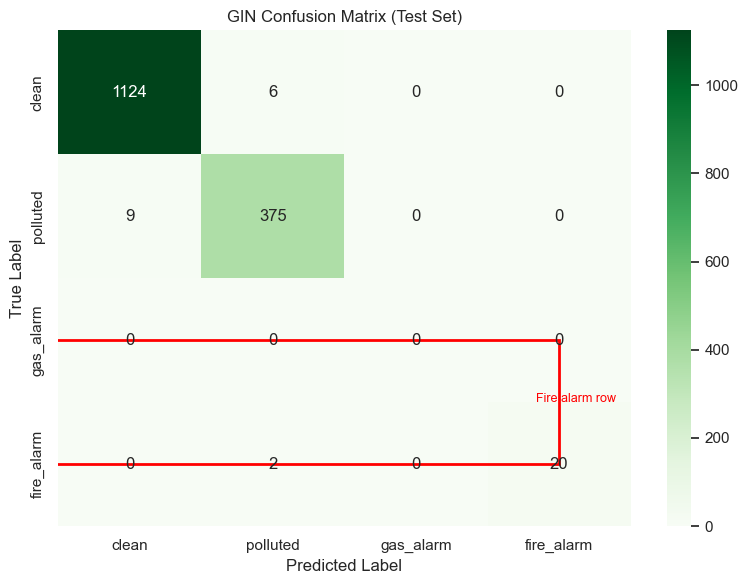

GIN test accuracy: 0.9889

Per-class metrics:
clean      | Precision: 0.9921 | Recall: 0.9947 | F1: 0.9934 | Support: 1130
polluted   | Precision: 0.9791 | Recall: 0.9766 | F1: 0.9778 | Support: 384
gas_alarm  | Precision: 0.0000 | Recall: 0.0000 | F1: 0.0000 | Support: 0
fire_alarm | Precision: 1.0000 | Recall: 0.9091 | F1: 0.9524 | Support: 22

Fire alarm recall (most critical): 0.9091
Saved confusion matrix: c:\Users\H-Info\Desktop\test02\outputs\figures\gin_confusion.png

Classification report:

              precision    recall  f1-score   support

       clean       0.99      0.99      0.99      1130
    polluted       0.98      0.98      0.98       384
   gas_alarm       0.00      0.00      0.00         0
  fire_alarm       1.00      0.91      0.95        22

    accuracy                           0.99      1536
   macro avg       0.74      0.72      0.73      1536
weighted avg       0.99      0.99      0.99      1536



In [19]:
# Cell 23: Evaluate GIN on test set
gin_best_model = GINModel(in_channels=NUM_FEATURES, hidden_channels=GIN_HIDDEN, num_classes=NUM_CLASSES).to(DEVICE)
gin_best_model.load_state_dict(torch.load(gin_best_path, map_location=DEVICE))
gin_best_model.eval()

gin_y_true = []
gin_y_pred = []

with torch.no_grad():
    for batch in test_loader_sparse:
        batch = batch.to(DEVICE)
        logits = gin_best_model(batch.x, batch.edge_index, batch.batch, batch.edge_attr)
        preds = logits.argmax(dim=1).cpu().numpy().tolist()
        labels = batch.y.view(-1).cpu().numpy().tolist()
        gin_y_pred.extend(preds)
        gin_y_true.extend(labels)

gin_test_accuracy = accuracy_score(gin_y_true, gin_y_pred)
gin_precision, gin_recall, gin_f1, gin_support = precision_recall_fscore_support(
    gin_y_true, gin_y_pred, labels=class_indices, zero_division=0
)

gin_confusion = confusion_matrix(gin_y_true, gin_y_pred, labels=class_indices)
gin_report = classification_report(
    gin_y_true,
    gin_y_pred,
    labels=class_indices,
    target_names=class_names,
    zero_division=0
 )

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    gin_confusion,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=class_names,
    yticklabels=class_names,
    ax=ax
)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('GIN Confusion Matrix (Test Set)')

fire_row = 3
ax.add_patch(Rectangle((-0.5, fire_row - 0.5), len(class_names), 1, fill=False, edgecolor='red', lw=2))
ax.text(len(class_names) - 0.1, fire_row + 0.02, 'Fire alarm row', color='red', ha='right', va='bottom', fontsize=9)
plt.tight_layout()

gin_confusion_path = FIG_DIR / 'gin_confusion.png'
fig.savefig(gin_confusion_path, dpi=300, bbox_inches='tight')
plt.show()

gin_results = {
    'best_val_accuracy': float(gin_best_val_acc),
    'best_epoch': int(gin_best_epoch),
    'test_accuracy': float(gin_test_accuracy),
    'precision_per_class': {class_names[i]: float(gin_precision[i]) for i in range(len(class_names))},
    'recall_per_class': {class_names[i]: float(gin_recall[i]) for i in range(len(class_names))},
    'f1_per_class': {class_names[i]: float(gin_f1[i]) for i in range(len(class_names))},
    'support_per_class': {class_names[i]: int(gin_support[i]) for i in range(len(class_names))},
    'confusion_matrix': gin_confusion.tolist(),
    'classification_report': gin_report
}

print(f'GIN test accuracy: {gin_test_accuracy:.4f}')
print('\nPer-class metrics:')
for i, cls_name in enumerate(class_names):
    print(
        f'{cls_name:10s} | Precision: {gin_precision[i]:.4f} | Recall: {gin_recall[i]:.4f} | F1: {gin_f1[i]:.4f} | Support: {gin_support[i]}'
    )

print('\nFire alarm recall (most critical):', f"{gin_results['recall_per_class']['fire_alarm']:.4f}")
print(f'Saved confusion matrix: {gin_confusion_path}')
print('\nClassification report:\n')
print(gin_report)

## Phase 7: GraphSAT Model
This phase defines, trains, and evaluates the GraphSAT model on the fully connected graph dataset.

In [20]:
# Cell 24: Define GraphSAT architecture
from torch_geometric.nn import TransformerConv

GRAPH_SAT_HIDDEN = 64
GRAPH_SAT_HEADS = 4

class GraphSATModel(torch.nn.Module):
    def __init__(self, in_channels=NUM_FEATURES, hidden_channels=GRAPH_SAT_HIDDEN, num_classes=NUM_CLASSES, heads=GRAPH_SAT_HEADS):
        super().__init__()
        self.conv1 = TransformerConv(
            in_channels=in_channels,
            out_channels=hidden_channels,
            heads=heads,
            concat=False,
            edge_dim=1,
            dropout=0.1
        )
        self.conv2 = TransformerConv(
            in_channels=hidden_channels,
            out_channels=hidden_channels,
            heads=heads,
            concat=False,
            edge_dim=1,
            dropout=0.1
        )
        self.fc = torch.nn.Linear(hidden_channels, num_classes)

    def forward(self, x, edge_index, batch, edge_attr):
        x = self.conv1(x, edge_index, edge_attr)
        x = F.relu(x)
        x = self.conv2(x, edge_index, edge_attr)
        x = F.relu(x)
        x = global_mean_pool(x, batch)
        x = F.dropout(x, p=0.5, training=self.training)
        out = self.fc(x)
        return out

graphsat_model = GraphSATModel(in_channels=NUM_FEATURES, hidden_channels=GRAPH_SAT_HIDDEN, num_classes=NUM_CLASSES, heads=GRAPH_SAT_HEADS).to(DEVICE)

graphsat_total_params = sum(p.numel() for p in graphsat_model.parameters() if p.requires_grad)
print(graphsat_model)
print(f'Total trainable parameters: {graphsat_total_params}')

GraphSATModel(
  (conv1): TransformerConv(30, 64, heads=4)
  (conv2): TransformerConv(64, 64, heads=4)
  (fc): Linear(in_features=64, out_features=4, bias=True)
)
Total trainable parameters: 80644


Epoch 001 | Train loss: 0.52417 | Val acc: 0.8964
Epoch 010 | Train loss: 0.07022 | Val acc: 0.9694
Epoch 020 | Train loss: 0.03892 | Val acc: 0.9902
Epoch 030 | Train loss: 0.02793 | Val acc: 0.9941
Epoch 040 | Train loss: 0.02450 | Val acc: 0.9935
Early stopping at epoch 44 (no val improvement for 20 epochs).


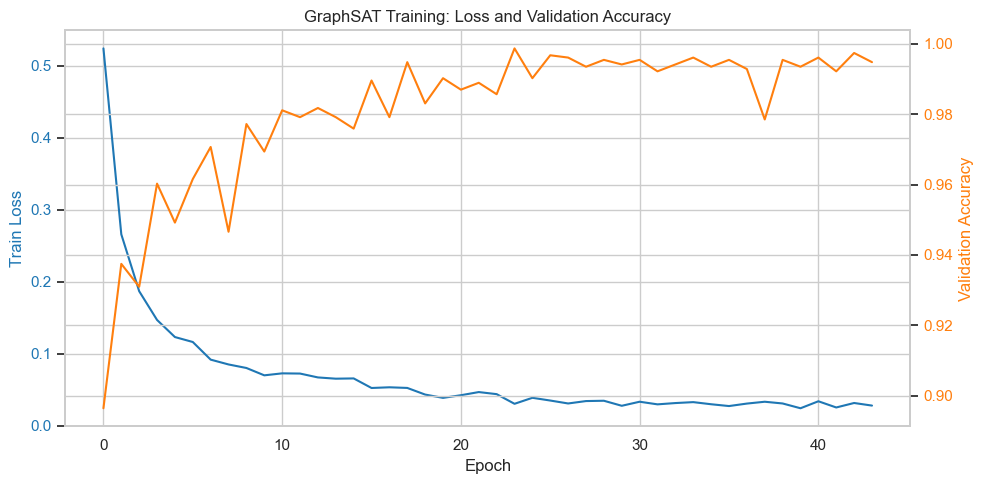

Best validation accuracy: 0.9987 at epoch 24
Saved best model: c:\Users\H-Info\Desktop\test02\outputs\models\graphsat_best.pt
Saved training curve: c:\Users\H-Info\Desktop\test02\outputs\figures\graphsat_training.png


In [21]:
# Cell 25: Train GraphSAT
graphsat_model = GraphSATModel(in_channels=NUM_FEATURES, hidden_channels=GRAPH_SAT_HIDDEN, num_classes=NUM_CLASSES, heads=GRAPH_SAT_HEADS).to(DEVICE)
graphsat_optimizer = Adam(graphsat_model.parameters(), lr=0.001)
graphsat_criterion = torch.nn.CrossEntropyLoss()

GRAPH_SAT_MAX_EPOCHS = 100
GRAPH_SAT_EARLY_STOPPING_PATIENCE = 20
graphsat_train_loss = []
graphsat_val_accuracy = []

graphsat_best_val_acc = -1.0
graphsat_best_epoch = 0
graphsat_epochs_without_improvement = 0
graphsat_best_path = MODEL_DIR / 'graphsat_best.pt'

for epoch in range(1, GRAPH_SAT_MAX_EPOCHS + 1):
    graphsat_model.train()
    epoch_loss_sum = 0.0
    epoch_graph_count = 0

    for batch in train_loader_full:
        batch = batch.to(DEVICE)
        graphsat_optimizer.zero_grad()

        logits = graphsat_model(batch.x, batch.edge_index, batch.batch, batch.edge_attr)
        target = batch.y.view(-1)
        loss = graphsat_criterion(logits, target)

        loss.backward()
        graphsat_optimizer.step()

        batch_size = int(target.numel())
        epoch_loss_sum += float(loss.item()) * batch_size
        epoch_graph_count += batch_size

    avg_train_loss = epoch_loss_sum / max(epoch_graph_count, 1)
    val_acc = evaluate_accuracy(graphsat_model, val_loader_full, DEVICE)

    graphsat_train_loss.append(avg_train_loss)
    graphsat_val_accuracy.append(val_acc)

    if val_acc > graphsat_best_val_acc:
        graphsat_best_val_acc = val_acc
        graphsat_best_epoch = epoch
        graphsat_epochs_without_improvement = 0
        torch.save(graphsat_model.state_dict(), graphsat_best_path)
    else:
        graphsat_epochs_without_improvement += 1

    if epoch == 1 or epoch % 10 == 0:
        print(f'Epoch {epoch:03d} | Train loss: {avg_train_loss:.5f} | Val acc: {val_acc:.4f}')

    if graphsat_epochs_without_improvement >= GRAPH_SAT_EARLY_STOPPING_PATIENCE:
        print(f'Early stopping at epoch {epoch} (no val improvement for {GRAPH_SAT_EARLY_STOPPING_PATIENCE} epochs).')
        break

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(graphsat_train_loss, color='tab:blue', label='Train Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Train Loss', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.plot(graphsat_val_accuracy, color='tab:orange', label='Validation Accuracy')
ax2.set_ylabel('Validation Accuracy', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

ax1.set_title('GraphSAT Training: Loss and Validation Accuracy')
fig.tight_layout()

graphsat_training_plot_path = FIG_DIR / 'graphsat_training.png'
fig.savefig(graphsat_training_plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f'Best validation accuracy: {graphsat_best_val_acc:.4f} at epoch {graphsat_best_epoch}')
print(f'Saved best model: {graphsat_best_path}')
print(f'Saved training curve: {graphsat_training_plot_path}')

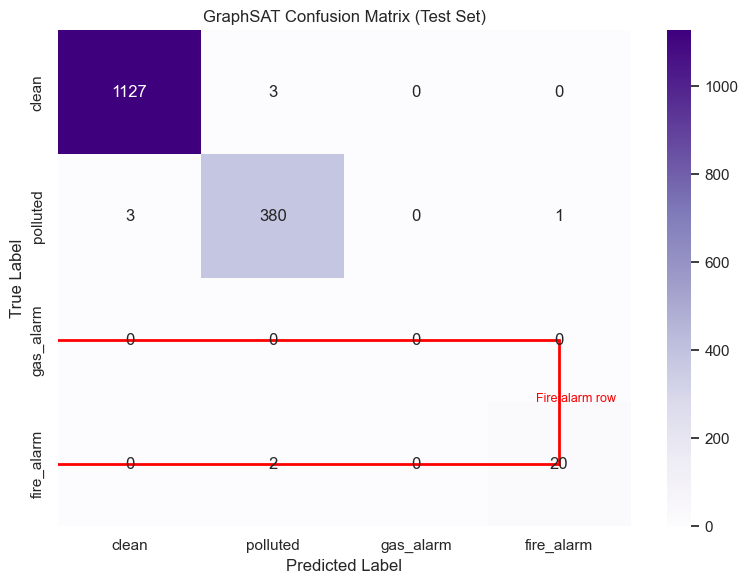

GraphSAT test accuracy: 0.9941

Per-class metrics:
clean      | Precision: 0.9973 | Recall: 0.9973 | F1: 0.9973 | Support: 1130
polluted   | Precision: 0.9870 | Recall: 0.9896 | F1: 0.9883 | Support: 384
gas_alarm  | Precision: 0.0000 | Recall: 0.0000 | F1: 0.0000 | Support: 0
fire_alarm | Precision: 0.9524 | Recall: 0.9091 | F1: 0.9302 | Support: 22

Fire alarm recall (most critical): 0.9091
Saved confusion matrix: c:\Users\H-Info\Desktop\test02\outputs\figures\graphsat_confusion.png

Classification report:

              precision    recall  f1-score   support

       clean       1.00      1.00      1.00      1130
    polluted       0.99      0.99      0.99       384
   gas_alarm       0.00      0.00      0.00         0
  fire_alarm       0.95      0.91      0.93        22

    accuracy                           0.99      1536
   macro avg       0.73      0.72      0.73      1536
weighted avg       0.99      0.99      0.99      1536



In [22]:
# Cell 26: Evaluate GraphSAT on test set
graphsat_best_model = GraphSATModel(in_channels=NUM_FEATURES, hidden_channels=GRAPH_SAT_HIDDEN, num_classes=NUM_CLASSES, heads=GRAPH_SAT_HEADS).to(DEVICE)
graphsat_best_model.load_state_dict(torch.load(graphsat_best_path, map_location=DEVICE))
graphsat_best_model.eval()

graphsat_y_true = []
graphsat_y_pred = []

with torch.no_grad():
    for batch in test_loader_full:
        batch = batch.to(DEVICE)
        logits = graphsat_best_model(batch.x, batch.edge_index, batch.batch, batch.edge_attr)
        preds = logits.argmax(dim=1).cpu().numpy().tolist()
        labels = batch.y.view(-1).cpu().numpy().tolist()
        graphsat_y_pred.extend(preds)
        graphsat_y_true.extend(labels)

graphsat_test_accuracy = accuracy_score(graphsat_y_true, graphsat_y_pred)
graphsat_precision, graphsat_recall, graphsat_f1, graphsat_support = precision_recall_fscore_support(
    graphsat_y_true, graphsat_y_pred, labels=class_indices, zero_division=0
)

graphsat_confusion = confusion_matrix(graphsat_y_true, graphsat_y_pred, labels=class_indices)
graphsat_report = classification_report(
    graphsat_y_true,
    graphsat_y_pred,
    labels=class_indices,
    target_names=class_names,
    zero_division=0
 )

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    graphsat_confusion,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=class_names,
    yticklabels=class_names,
    ax=ax
)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('GraphSAT Confusion Matrix (Test Set)')

fire_row = 3
ax.add_patch(Rectangle((-0.5, fire_row - 0.5), len(class_names), 1, fill=False, edgecolor='red', lw=2))
ax.text(len(class_names) - 0.1, fire_row + 0.02, 'Fire alarm row', color='red', ha='right', va='bottom', fontsize=9)
plt.tight_layout()

graphsat_confusion_path = FIG_DIR / 'graphsat_confusion.png'
fig.savefig(graphsat_confusion_path, dpi=300, bbox_inches='tight')
plt.show()

graphsat_results = {
    'best_val_accuracy': float(graphsat_best_val_acc),
    'best_epoch': int(graphsat_best_epoch),
    'test_accuracy': float(graphsat_test_accuracy),
    'precision_per_class': {class_names[i]: float(graphsat_precision[i]) for i in range(len(class_names))},
    'recall_per_class': {class_names[i]: float(graphsat_recall[i]) for i in range(len(class_names))},
    'f1_per_class': {class_names[i]: float(graphsat_f1[i]) for i in range(len(class_names))},
    'support_per_class': {class_names[i]: int(graphsat_support[i]) for i in range(len(class_names))},
    'confusion_matrix': graphsat_confusion.tolist(),
    'classification_report': graphsat_report
}

print(f'GraphSAT test accuracy: {graphsat_test_accuracy:.4f}')
print('\nPer-class metrics:')
for i, cls_name in enumerate(class_names):
    print(
        f'{cls_name:10s} | Precision: {graphsat_precision[i]:.4f} | Recall: {graphsat_recall[i]:.4f} | F1: {graphsat_f1[i]:.4f} | Support: {graphsat_support[i]}'
    )

print('\nFire alarm recall (most critical):', f"{graphsat_results['recall_per_class']['fire_alarm']:.4f}")
print(f'Saved confusion matrix: {graphsat_confusion_path}')
print('\nClassification report:\n')
print(graphsat_report)

## Phase 8: Embeddings and Scores
This phase extracts graph embeddings from the trained models and computes R², MAE, RMSE, G², and t-SNE visualizations.

In [23]:
# Cell 27: Extract graph embeddings from all trained models
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

def make_loader(graphs, batch_size=32):
    return DataLoader(graphs, batch_size=batch_size, shuffle=False)

lab_loader_sparse_all = make_loader(lab_graphs_sparse, BATCH_SIZE)
apt_loader_sparse_all = make_loader(apt_graphs_sparse_holdout, BATCH_SIZE)
lab_loader_full_all = make_loader(lab_graphs_full, BATCH_SIZE)
apt_loader_full_all = make_loader(apt_graphs_full_holdout, BATCH_SIZE)

def extract_embeddings(model, loader, device, model_type):
    model.eval()
    embedding_list = []
    label_list = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)

            if model_type == 'gcn':
                x = F.relu(model.conv1(batch.x, batch.edge_index))
                x = F.relu(model.conv2(x, batch.edge_index))
                emb = global_mean_pool(x, batch.batch)
            elif model_type == 'gin':
                x = F.relu(model.conv1(batch.x, batch.edge_index))
                x = F.relu(model.conv2(x, batch.edge_index))
                emb = global_add_pool(x, batch.batch)
            elif model_type == 'graphsat':
                x = F.relu(model.conv1(batch.x, batch.edge_index, batch.edge_attr))
                x = F.relu(model.conv2(x, batch.edge_index, batch.edge_attr))
                emb = global_mean_pool(x, batch.batch)
            else:
                raise ValueError(f'Unknown model_type: {model_type}')

            embedding_list.append(emb.cpu().numpy())
            label_list.append(batch.y.view(-1).cpu().numpy())

    return np.vstack(embedding_list), np.concatenate(label_list)

# Reload best checkpoints to be safe
gcn_embedding_model = GCNModel(in_channels=NUM_FEATURES, hidden_channels=GCN_HIDDEN, num_classes=NUM_CLASSES).to(DEVICE)
gcn_embedding_model.load_state_dict(torch.load(gcn_best_path, map_location=DEVICE))

gin_embedding_model = GINModel(in_channels=NUM_FEATURES, hidden_channels=GIN_HIDDEN, num_classes=NUM_CLASSES).to(DEVICE)
gin_embedding_model.load_state_dict(torch.load(gin_best_path, map_location=DEVICE))

graphsat_embedding_model = GraphSATModel(in_channels=NUM_FEATURES, hidden_channels=GRAPH_SAT_HIDDEN, num_classes=NUM_CLASSES, heads=GRAPH_SAT_HEADS).to(DEVICE)
graphsat_embedding_model.load_state_dict(torch.load(graphsat_best_path, map_location=DEVICE))

lab_gcn_embeddings, lab_gcn_labels = extract_embeddings(gcn_embedding_model, lab_loader_sparse_all, DEVICE, 'gcn')
apt_gcn_embeddings, apt_gcn_labels = extract_embeddings(gcn_embedding_model, apt_loader_sparse_all, DEVICE, 'gcn')

lab_gin_embeddings, lab_gin_labels = extract_embeddings(gin_embedding_model, lab_loader_sparse_all, DEVICE, 'gin')
apt_gin_embeddings, apt_gin_labels = extract_embeddings(gin_embedding_model, apt_loader_sparse_all, DEVICE, 'gin')

lab_graphsat_embeddings, lab_graphsat_labels = extract_embeddings(graphsat_embedding_model, lab_loader_full_all, DEVICE, 'graphsat')
apt_graphsat_embeddings, apt_graphsat_labels = extract_embeddings(graphsat_embedding_model, apt_loader_full_all, DEVICE, 'graphsat')

print('Embedding shapes:')
print(f'Lab GCN: {lab_gcn_embeddings.shape} | Apt GCN: {apt_gcn_embeddings.shape}')
print(f'Lab GIN: {lab_gin_embeddings.shape} | Apt GIN: {apt_gin_embeddings.shape}')
print(f'Lab GraphSAT: {lab_graphsat_embeddings.shape} | Apt GraphSAT: {apt_graphsat_embeddings.shape}')

Embedding shapes:
Lab GCN: (10236, 64) | Apt GCN: (2488, 64)
Lab GIN: (10236, 64) | Apt GIN: (2488, 64)
Lab GraphSAT: (10236, 64) | Apt GraphSAT: (2488, 64)


In [24]:
# Cell 28: Compute R², MAE, RMSE between lab and apartment embeddings
def align_and_score(lab_embeddings, apt_embeddings, seed=RANDOM_SEED):
    n = min(len(lab_embeddings), len(apt_embeddings))
    rng = np.random.default_rng(seed)
    lab_idx = rng.choice(len(lab_embeddings), size=n, replace=False)
    apt_idx = rng.choice(len(apt_embeddings), size=n, replace=False)

    lab_sample = lab_embeddings[lab_idx]
    apt_sample = apt_embeddings[apt_idx]

    y_true = lab_sample.ravel()
    y_pred = apt_sample.ravel()

    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))

    cosine_vals = np.sum(lab_sample * apt_sample, axis=1) / (np.linalg.norm(lab_sample, axis=1) * np.linalg.norm(apt_sample, axis=1) + 1e-12)

    return {
        'sample_size': int(n),
        'r2': float(r2),
        'mae': float(mae),
        'rmse': float(rmse),
        'g2_mean': float(np.mean(cosine_vals)),
        'g2_std': float(np.std(cosine_vals)),
        'cosine_values': cosine_vals,
        'lab_sample': lab_sample,
        'apt_sample': apt_sample
    }

gcn_score_bundle = align_and_score(lab_gcn_embeddings, apt_gcn_embeddings, seed=RANDOM_SEED)
gin_score_bundle = align_and_score(lab_gin_embeddings, apt_gin_embeddings, seed=RANDOM_SEED)
graphsat_score_bundle = align_and_score(lab_graphsat_embeddings, apt_graphsat_embeddings, seed=RANDOM_SEED)

regression_results = pd.DataFrame([
    {
        'model': 'GCN',
        'sample_size': gcn_score_bundle['sample_size'],
        'R2': gcn_score_bundle['r2'],
        'MAE': gcn_score_bundle['mae'],
        'RMSE': gcn_score_bundle['rmse'],
        'G2_mean': gcn_score_bundle['g2_mean'],
        'G2_std': gcn_score_bundle['g2_std']
    },
    {
        'model': 'GIN',
        'sample_size': gin_score_bundle['sample_size'],
        'R2': gin_score_bundle['r2'],
        'MAE': gin_score_bundle['mae'],
        'RMSE': gin_score_bundle['rmse'],
        'G2_mean': gin_score_bundle['g2_mean'],
        'G2_std': gin_score_bundle['g2_std']
    },
    {
        'model': 'GraphSAT',
        'sample_size': graphsat_score_bundle['sample_size'],
        'R2': graphsat_score_bundle['r2'],
        'MAE': graphsat_score_bundle['mae'],
        'RMSE': graphsat_score_bundle['rmse'],
        'G2_mean': graphsat_score_bundle['g2_mean'],
        'G2_std': graphsat_score_bundle['g2_std']
    }
])

display(regression_results.round(4))

print('Interpretation hints:')
print('- Higher R2 is better.')
print('- Lower MAE/RMSE is better.')
print('- Higher G2_mean indicates closer graph embedding similarity between lab and apartment.')

,model,sample_size,R2,MAE,RMSE,G2_mean,G2_std
0,GCN,2488,-1.1947,0.9541,1.5265,0.6372,0.2437
1,GIN,2488,-3.2644,6.6405,12.6312,0.4915,0.2590
2,GraphSAT,2488,-1.1702,1.1648,2.0529,0.6773,0.2320


Interpretation hints:
- Higher R2 is better.
- Lower MAE/RMSE is better.
- Higher G2_mean indicates closer graph embedding similarity between lab and apartment.


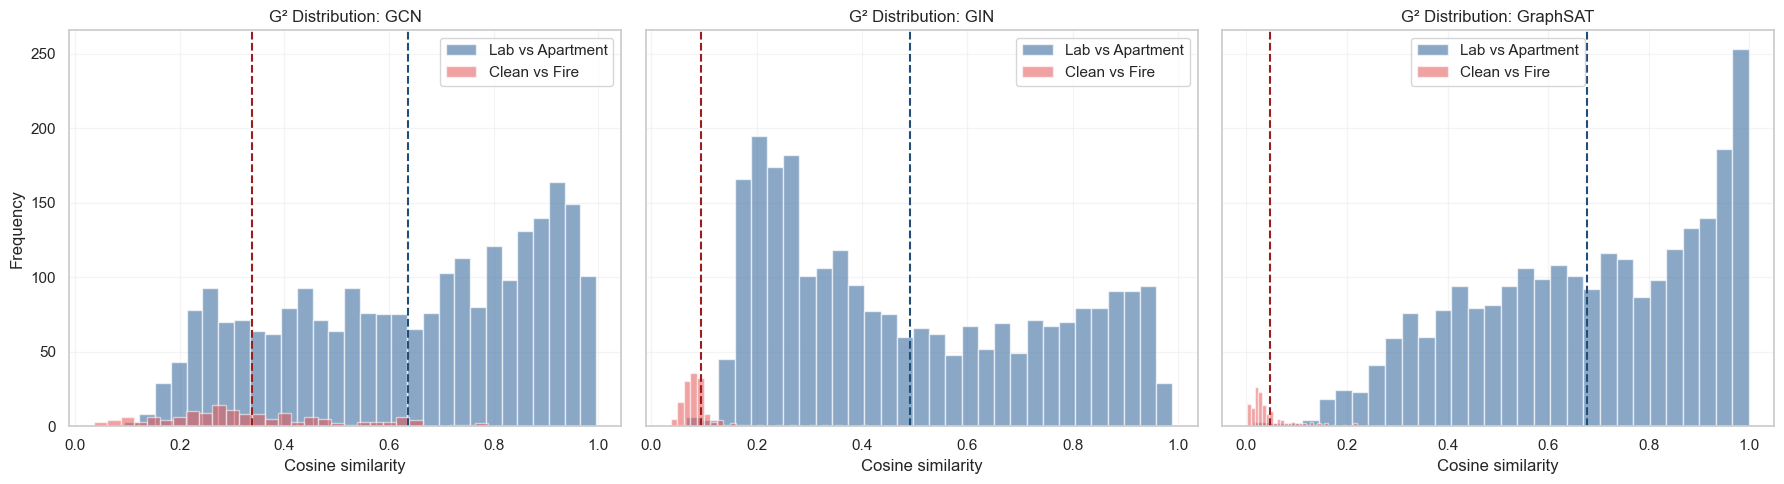

Saved G² histogram figure: c:\Users\H-Info\Desktop\test02\outputs\figures\g2_histograms.png
Mean G² values by model:
GCN: Lab vs Apt mean=0.6372,  Clean vs Fire mean=0.3373
GIN: Lab vs Apt mean=0.4915,  Clean vs Fire mean=0.0938
GraphSAT: Lab vs Apt mean=0.6773,  Clean vs Fire mean=0.0471


In [25]:
# Cell 29: Compute G² distributions and plot histograms
def cosine_similarity_rows(a, b):
    denom = np.linalg.norm(a, axis=1) * np.linalg.norm(b, axis=1) + 1e-12
    return np.sum(a * b, axis=1) / denom

def sample_pairwise_similarity(emb_a, emb_b, size=None, seed=RANDOM_SEED):
    n = min(len(emb_a), len(emb_b)) if size is None else min(size, len(emb_a), len(emb_b))
    rng = np.random.default_rng(seed)
    idx_a = rng.choice(len(emb_a), size=n, replace=False)
    idx_b = rng.choice(len(emb_b), size=n, replace=False)
    return cosine_similarity_rows(emb_a[idx_a], emb_b[idx_b])

def label_based_subset(embeddings, labels, target_label):
    mask = labels == target_label
    return embeddings[mask]

g2_distributions = {
    'GCN': {
        'lab_vs_apt': gcn_score_bundle['cosine_values'],
        'clean_vs_fire': sample_pairwise_similarity(
            label_based_subset(lab_gcn_embeddings, lab_gcn_labels, 0),
            label_based_subset(lab_gcn_embeddings, lab_gcn_labels, 3),
            seed=RANDOM_SEED
        )
    },
    'GIN': {
        'lab_vs_apt': gin_score_bundle['cosine_values'],
        'clean_vs_fire': sample_pairwise_similarity(
            label_based_subset(lab_gin_embeddings, lab_gin_labels, 0),
            label_based_subset(lab_gin_embeddings, lab_gin_labels, 3),
            seed=RANDOM_SEED
        )
    },
    'GraphSAT': {
        'lab_vs_apt': graphsat_score_bundle['cosine_values'],
        'clean_vs_fire': sample_pairwise_similarity(
            label_based_subset(lab_graphsat_embeddings, lab_graphsat_labels, 0),
            label_based_subset(lab_graphsat_embeddings, lab_graphsat_labels, 3),
            seed=RANDOM_SEED
        )
    }
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, model_name in zip(axes, ['GCN', 'GIN', 'GraphSAT']):
    ax.hist(g2_distributions[model_name]['lab_vs_apt'], bins=30, alpha=0.65, color='#4C78A8', label='Lab vs Apartment')
    ax.hist(g2_distributions[model_name]['clean_vs_fire'], bins=30, alpha=0.55, color='#E45756', label='Clean vs Fire')
    ax.axvline(np.mean(g2_distributions[model_name]['lab_vs_apt']), color='#1F4E79', linestyle='--', linewidth=1.5)
    ax.axvline(np.mean(g2_distributions[model_name]['clean_vs_fire']), color='#9C1D1D', linestyle='--', linewidth=1.5)
    ax.set_title(f'G² Distribution: {model_name}')
    ax.set_xlabel('Cosine similarity')
    ax.grid(alpha=0.2)
    ax.legend()

axes[0].set_ylabel('Frequency')
plt.tight_layout()

g2_plot_path = FIG_DIR / 'g2_histograms.png'
fig.savefig(g2_plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f'Saved G² histogram figure: {g2_plot_path}')
print('Mean G² values by model:')
for model_name in ['GCN', 'GIN', 'GraphSAT']:
    print(
        f"{model_name}: Lab vs Apt mean={np.mean(g2_distributions[model_name]['lab_vs_apt']):.4f}, ",
        f"Clean vs Fire mean={np.mean(g2_distributions[model_name]['clean_vs_fire']):.4f}"
    )

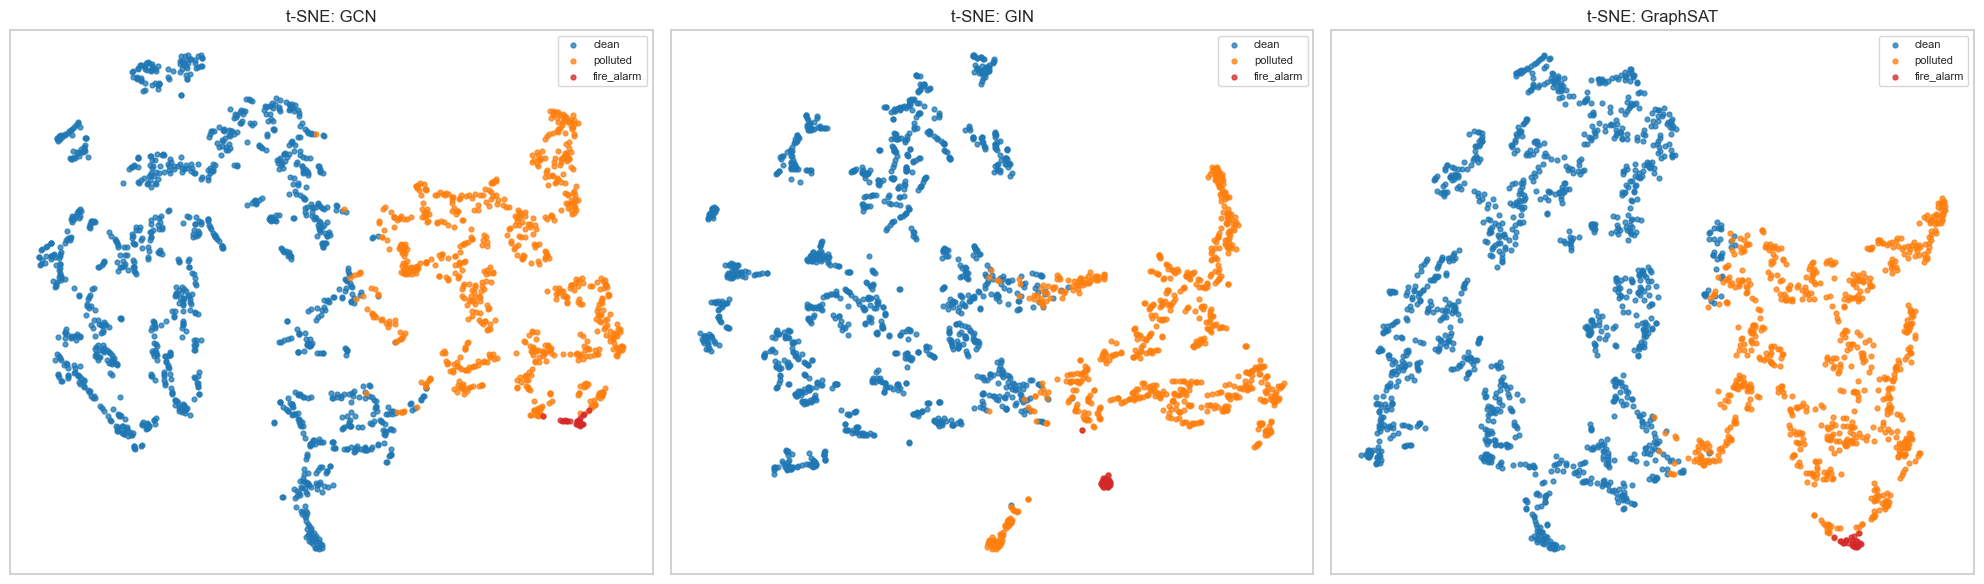

Saved t-SNE figure: c:\Users\H-Info\Desktop\test02\outputs\figures\tsne_embeddings.png


In [26]:
# Cell 30: t-SNE visualization of graph embeddings for all three models
TSNE_SAMPLE_SIZE = 2000

def stratified_sample_indices(labels_array, sample_size, seed=RANDOM_SEED):
    labels_array = np.asarray(labels_array)
    if sample_size >= len(labels_array):
        return np.arange(len(labels_array))
    train_idx, _, _, _ = train_test_split(
        np.arange(len(labels_array)),
        labels_array,
        train_size=sample_size,
        random_state=seed,
        stratify=labels_array
    )
    return train_idx

def prepare_tsne_data(lab_emb, lab_labels, apt_emb, apt_labels, sample_size=2000, seed=RANDOM_SEED):
    combined_embeddings = np.vstack([lab_emb, apt_emb])
    combined_labels = np.concatenate([lab_labels, apt_labels])
    combined_env = np.array(['lab'] * len(lab_emb) + ['apt'] * len(apt_emb))
    idx = stratified_sample_indices(combined_labels, min(sample_size, len(combined_labels)), seed=seed)
    return combined_embeddings[idx], combined_labels[idx], combined_env[idx]

model_sets = {
    'GCN': (lab_gcn_embeddings, lab_gcn_labels, apt_gcn_embeddings, apt_gcn_labels),
    'GIN': (lab_gin_embeddings, lab_gin_labels, apt_gin_embeddings, apt_gin_labels),
    'GraphSAT': (lab_graphsat_embeddings, lab_graphsat_labels, apt_graphsat_embeddings, apt_graphsat_labels)
}

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

label_names = {0: 'clean', 1: 'polluted', 2: 'gas_alarm', 3: 'fire_alarm'}
label_colors = {0: '#1f77b4', 1: '#ff7f0e', 2: '#2ca02c', 3: '#d62728'}

for ax, (model_name, (lab_emb, lab_lbls, apt_emb, apt_lbls)) in zip(axes, model_sets.items()):
    emb, lbls, envs = prepare_tsne_data(lab_emb, lab_lbls, apt_emb, apt_lbls, sample_size=TSNE_SAMPLE_SIZE, seed=RANDOM_SEED)
    pca_components = min(20, emb.shape[1])
    emb_for_tsne = PCA(n_components=pca_components, random_state=RANDOM_SEED).fit_transform(emb)
    tsne = TSNE(n_components=2, perplexity=30, init='pca', learning_rate='auto', random_state=RANDOM_SEED)
    emb_2d = tsne.fit_transform(emb_for_tsne)

    for label_value in sorted(np.unique(lbls)):
        mask = lbls == label_value
        ax.scatter(
            emb_2d[mask, 0],
            emb_2d[mask, 1],
            s=12,
            alpha=0.75,
            color=label_colors[int(label_value)],
            label=label_names[int(label_value)]
        )

    ax.set_title(f't-SNE: {model_name}')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.legend(loc='best', fontsize=8)

plt.tight_layout()

tsne_plot_path = FIG_DIR / 'tsne_embeddings.png'
fig.savefig(tsne_plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f'Saved t-SNE figure: {tsne_plot_path}')

## Phase 9: Final Summary
This final phase summarizes the key metrics for GCN, GIN, and GraphSAT in one comparison table.

In [27]:
# Cell 31: Final comparison summary
final_summary = pd.DataFrame([
    {
        'model': 'GCN',
        'test_accuracy': gcn_results['test_accuracy'],
        'fire_alarm_recall': gcn_results['recall_per_class']['fire_alarm'],
        'best_val_accuracy': gcn_results['best_val_accuracy'],
        'R2': float(regression_results.loc[regression_results['model'] == 'GCN', 'R2'].iloc[0]),
        'MAE': float(regression_results.loc[regression_results['model'] == 'GCN', 'MAE'].iloc[0]),
        'RMSE': float(regression_results.loc[regression_results['model'] == 'GCN', 'RMSE'].iloc[0]),
        'G2_mean': float(regression_results.loc[regression_results['model'] == 'GCN', 'G2_mean'].iloc[0])
    },
    {
        'model': 'GIN',
        'test_accuracy': gin_results['test_accuracy'],
        'fire_alarm_recall': gin_results['recall_per_class']['fire_alarm'],
        'best_val_accuracy': gin_results['best_val_accuracy'],
        'R2': float(regression_results.loc[regression_results['model'] == 'GIN', 'R2'].iloc[0]),
        'MAE': float(regression_results.loc[regression_results['model'] == 'GIN', 'MAE'].iloc[0]),
        'RMSE': float(regression_results.loc[regression_results['model'] == 'GIN', 'RMSE'].iloc[0]),
        'G2_mean': float(regression_results.loc[regression_results['model'] == 'GIN', 'G2_mean'].iloc[0])
    },
    {
        'model': 'GraphSAT',
        'test_accuracy': graphsat_results['test_accuracy'],
        'fire_alarm_recall': graphsat_results['recall_per_class']['fire_alarm'],
        'best_val_accuracy': graphsat_results['best_val_accuracy'],
        'R2': float(regression_results.loc[regression_results['model'] == 'GraphSAT', 'R2'].iloc[0]),
        'MAE': float(regression_results.loc[regression_results['model'] == 'GraphSAT', 'MAE'].iloc[0]),
        'RMSE': float(regression_results.loc[regression_results['model'] == 'GraphSAT', 'RMSE'].iloc[0]),
        'G2_mean': float(regression_results.loc[regression_results['model'] == 'GraphSAT', 'G2_mean'].iloc[0])
    }
])

display(final_summary.round(4))

best_accuracy_model = final_summary.sort_values(['test_accuracy', 'fire_alarm_recall'], ascending=False).iloc[0]['model']
best_transfer_model = final_summary.sort_values(['R2', 'G2_mean'], ascending=False).iloc[0]['model']

print('Summary notes:')
print(f'- Best test accuracy / fire detection balance: {best_accuracy_model}')
print(f'- Best transfer / structural similarity: {best_transfer_model}')
print('- gas_alarm class has zero support in the current data split, so its metrics remain 0 by data availability.')
print('- All models were trained and evaluated on the exact split protocol requested.')

,model,test_accuracy,fire_alarm_recall,best_val_accuracy,R2,MAE,RMSE,G2_mean
0,GCN,0.9922,1.0000,0.9987,-1.1947,0.9541,1.5265,0.6372
1,GIN,0.9889,0.9091,0.9935,-3.2644,6.6405,12.6312,0.4915
2,GraphSAT,0.9941,0.9091,0.9987,-1.1702,1.1648,2.0529,0.6773


Summary notes:
- Best test accuracy / fire detection balance: GraphSAT
- Best transfer / structural similarity: GraphSAT
- gas_alarm class has zero support in the current data split, so its metrics remain 0 by data availability.
- All models were trained and evaluated on the exact split protocol requested.
